In [1]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Dec 11 00:18:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:0A:00.0  On |                  N/A |
|  0%   36C    P8             20W /  370W |    2229MiB /  10240MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# !pip install boruta
# !pip install smote_variants
# !pip install lime
# !pip install signaturizer

In [4]:
#import default and other essential libraries
import os
import numpy as np
import pandas as pd
import sklearn
import joblib
import pickle
import csv
import sys
import random
import seaborn as sns
from functools import reduce
import matplotlib.backends.backend_pdf
import matplotlib.pyplot as plt
import tensorflow as tf

In [5]:
#Packages to split data and other preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.decomposition import PCA
from boruta import BorutaPy
from imblearn.pipeline import Pipeline as sample_pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

In [6]:
#Import Classifiers
from sklearn import svm
import smote_variants as sv
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
## Package for calculating accuracy and analysis
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score, cohen_kappa_score, f1_score, precision_score, recall_score, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold
from lime.lime_tabular import LimeTabularExplainer

In [8]:
from signaturizer import Signaturizer
from tqdm import tqdm

In [9]:
def handle_missing_values(data):
    print('Handling missing values')
    data = data.replace([np.inf, -np.inf, "", " "], np.nan)
    data = data.replace(["", " "], np.nan)
    for i in data.columns:
        data[i] = data[i].fillna(data[i].mean())
    return data

def Feature_Signaturizer(dat):
    sig_df=pd.DataFrame()
    desc=['A','B','C','D','E']
    for dsc in tqdm(desc):
        for i in range(1,6):
            sign = Signaturizer(dsc+str(i), local=True)
            results = sign.predict(dat)
            df=pd.DataFrame(results.signature)
            for clm in list(df.columns):
                df=df.rename(columns={clm:dsc+str(i)+'_'+str(clm)})
            sig_df=pd.concat([sig_df,df],axis = 1)
    sig_df = handle_missing_values(sig_df)
    res = pd.DataFrame()
    res['smiles'] = dat
    res = pd.concat([res,sig_df],axis = 1)
    return res

In [10]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'AID_1208_datatable_all.csv') ### features in columns,molecules in rows
# 1. 根据列名为 PUBCHEM_CID 的取值去除重复的
data = data.drop_duplicates(subset='PUBCHEM_CID')

# 2. 替换 PUBCHEM_ACTIVITY_OUTCOME 列的取值
data['PUBCHEM_ACTIVITY_OUTCOME'] = data['PUBCHEM_ACTIVITY_OUTCOME'].replace({
    'Active': 1,
    'Inactive': 0,
    'Unspecified': np.nan
})

# 将 'Status' 列名修改为 'status'
data = data.rename(columns={'PUBCHEM_ACTIVITY_OUTCOME': 'status'})

# 3. 删除 SMILES 和 PUBCHEM_ACTIVITY_OUTCOME 两列中任一有空值的行
data = data.dropna(subset=['SMILES', 'status'])

# 4. 重新设置索引
data.reset_index(drop=True, inplace=True)

# 输出处理后的数据
data

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,SMILES,status
0,8,48413193,8486.0,C1=C(SC(=N1)N)[N+](=O)[O-],1.0
1,11,48413129,177.0,CC=O,1.0
2,12,48413131,5324279.0,C/C=N/O,0.0
3,13,48413132,178.0,CC(=O)N,1.0
4,14,48413133,1983.0,CC(=O)NC1=CC=C(C=C1)O,1.0
...,...,...,...,...,...
1175,1235,48414651,62158.0,C1=CC(=C(C=C1[N+](=O)[O-])OCCO)NCCO,0.0
1176,1236,48414652,24860542.0,CC1(CC2=C(O1)C(=CC(=C2)Cl)C(=O)NC3C[C@H]4CCC(C...,0.0
1177,1237,48414653,5281576.0,C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1,0.0
1178,1238,48414654,2724192.0,CC(=O)[O-].CC(=O)[O-].O.O.[Zn+2],0.0


In [11]:
# 提取 SMILES 列
data_smiles = data['SMILES']
# 使用 Feature_Signaturizer 计算特征
data_features = Feature_Signaturizer(data_smiles)

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]
Parsing SMILES: 0it [00:00, ?it/s]
Parsing SMILES: 1180it [00:00, 7373.37it/s][A

Generating signatures:   0%|                                                                    | 0/10 [00:00<?, ?it/s]

1/1 [==============================] - 0s 46ms/step



Generating signatures:  10%|██████                                                      | 1/10 [00:00<00:03,  2.53it/s]

1/1 [==============================] - 0s 21ms/step



Generating signatures:  20%|████████████                                                | 2/10 [00:00<00:02,  3.10it/s]

...

1/1 [==============================] - 0s 24ms/step



Generating signatures:  90%|██████████████████████████████████████████████████████      | 9/10 [00:02<00:00,  3.63it/s]

1/1 [==============================] - 0s 46ms/step



100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:41<00:00, 20.26s/it]

Handling missing values


In [12]:
# 保留原始的 'status' 列
data = pd.concat([data_features, data['status']], axis=1)
data.to_csv('data_1208.csv')
# 打印查看结果
print(data)

                                                 smiles      A1_0      A1_1  \
0                            C1=C(SC(=N1)N)[N+](=O)[O-] -0.093968 -0.093967   
1                                                  CC=O -0.093480 -0.089256   
2                                               C/C=N/O -0.094337 -0.094267   
3                                               CC(=O)N -0.096465  0.053733   
4                                 CC(=O)NC1=CC=C(C=C1)O -0.094766  0.099283   
...                                                 ...       ...       ...   
1175                C1=CC(=C(C=C1[N+](=O)[O-])OCCO)NCCO -0.093039 -0.094334   
1176  CC1(CC2=C(O1)C(=CC(=C2)Cl)C(=O)NC3C[C@H]4CCC(C... -0.093327  0.087531   
1177  C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1  0.086597  0.097404   
1178                   CC(=O)[O-].CC(=O)[O-].O.O.[Zn+2] -0.100736 -0.058085   
1179               CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2] -0.097245  0.073241   

          A1_2      A1_3      A1_4      A1_5      A

In [13]:
# dropping ALL duplicate values, if any
data.drop_duplicates(subset ="smiles", keep = 'first', inplace = True, ignore_index = True)
data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,C1=C(SC(=N1)N)[N+](=O)[O-],-0.093968,-0.093967,0.093969,0.057746,0.093969,0.093967,-0.093969,-0.093969,-0.093884,...,0.045350,-0.047832,-0.075688,-0.014491,0.111776,0.116129,0.118240,-0.035231,0.041989,1.0
1,CC=O,-0.093479,-0.089258,0.069801,-0.090986,-0.082043,-0.043359,0.091742,-0.093448,0.089061,...,-0.116404,0.065310,-0.059638,0.008421,-0.018185,-0.046916,-0.002449,0.137647,0.030377,1.0
2,C/C=N/O,-0.094336,-0.094267,-0.061746,-0.030467,-0.084787,-0.086779,0.066083,-0.093192,0.082983,...,-0.104732,0.103063,0.032510,0.105347,-0.053153,0.019736,-0.092859,0.018258,0.047839,0.0
3,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,1.0
4,CC(=O)NC1=CC=C(C=C1)O,-0.094767,0.099285,-0.069983,0.078858,0.014583,0.099227,0.099023,-0.099302,-0.096730,...,0.043367,-0.080618,0.056817,0.146075,0.018187,-0.044958,0.020963,0.084850,0.095499,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,C1=CC(=C(C=C1[N+](=O)[O-])OCCO)NCCO,-0.093038,-0.094335,0.095204,-0.046846,0.095202,0.063424,-0.095204,-0.095204,-0.095197,...,0.081276,-0.075611,0.121933,0.039703,0.006569,0.126562,0.004939,0.047710,-0.080002,0.0
1176,CC1(CC2=C(O1)C(=CC(=C2)Cl)C(=O)NC3C[C@H]4CCC(C...,-0.093343,0.087515,-0.104545,-0.101462,-0.099453,0.056369,0.107227,0.108413,-0.046003,...,-0.173945,0.010049,-0.053734,-0.035837,-0.067844,-0.067368,-0.062793,0.003713,0.078850,0.0
1177,C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1,0.086594,0.097406,0.096966,-0.097145,0.097028,-0.091569,-0.071954,0.097492,0.096533,...,-0.141212,-0.046718,-0.069887,0.049093,-0.093039,-0.117753,0.079444,0.002861,0.134517,0.0
1178,CC(=O)[O-].CC(=O)[O-].O.O.[Zn+2],-0.100737,-0.058030,0.092190,0.082473,0.097876,0.100723,0.051282,-0.100834,-0.095762,...,0.044552,-0.055257,0.027439,0.102704,-0.073929,-0.123453,0.121928,-0.054320,0.099869,0.0


In [14]:
def Boruta_Filteration(X_train,y_train,X_test,y_test):
    #### making files for boruta
    features = [f for f in X_train.columns if f not in ['status']]
    X_train_boruta = X_train[features].values
    Y_train_boruta = y_train.values.ravel()
    X_test_boruta = X_test[features].values
    Y_test_boruta = y_test.values.ravel()

    print('Before filteration\nTrain shape\n',X_train_boruta.shape,'\nTest shape\n',X_test_boruta.shape)

    ### implementing boruta

    # define random forest classifier, with utilising all cores and
    # sampling in proportion to y labels
    rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

    # define Boruta feature selection method
    feat_selector = BorutaPy(rf, n_estimators=100, random_state=1)

    # find all relevant features - 5 features should be selected
    feat_selector.fit(X_train_boruta, Y_train_boruta)

    # check selected features - first 5 features are selected
    feat_selector.support_

    # check ranking of features
    feat_selector.ranking_

    # call transform() on X to filter it down to selected features
    X_train_filtered = feat_selector.transform(X_train_boruta)
    X_test_filtered = feat_selector.transform(X_test_boruta)

    ### name of the features selected####
    final_features = list()
    indexes = np.where(feat_selector.support_ == True)
    for x in np.nditer(indexes):
        final_features.append(features[x])

    print('# of Features selected:',len(final_features))

    X_train_filtered=pd.DataFrame(X_train_filtered,columns=final_features)
    X_test_filtered=pd.DataFrame(X_test_filtered,columns=final_features)

    print('After filteration\nTrain shape\n',X_train_filtered.shape,'\nTest shape\n',X_test_filtered.shape)

    return X_train_filtered,X_test_filtered,Y_train_boruta,Y_test_boruta,final_features

In [15]:
'''
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        #plt.legend(loc="lower right")
        plt.show()
'''

'\ndef TSNE_plot(data,data_labels):\n        tsne = TSNE(n_components=2, random_state=50)\n        transformed_data = tsne.fit_transform(data)\n        k = np.array(transformed_data)\n        Group=["Class 0","Class 1"]\n        plt.scatter(k[:, 0],k[:, 1], c=data_labels)\n        #plt.legend(loc="lower right")\n        plt.show()\n'

In [16]:
def Smote(traindata,trainlabel,prop):
        oversampler= sv.MSMOTE(proportion=prop,random_state=50)
        X_samp, y_samp= oversampler.sample(traindata.values,trainlabel.values)     
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()

In [17]:
# Set random seed to maintain the randomness of each hyperparameter tuning run
def seed_all():
    np.random.seed(123)
    tf.random.set_seed(123)
seed_all()

In [18]:
# Make a new directory for HyperParameter Tuning
os.mkdir('AID_1208')

In [19]:
# FROM = Path of directory from which to load the preprocessed signaturizer file
FROM='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao'
# TO = Path of the newly made HyperParameter Tuning directory
TO='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao/AID_1208/'

# Set the HPTuning directory as the current working directory
os.chdir(TO)

In [20]:
Data=data.dropna()
Data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,C1=C(SC(=N1)N)[N+](=O)[O-],-0.093968,-0.093967,0.093969,0.057746,0.093969,0.093967,-0.093969,-0.093969,-0.093884,...,0.045350,-0.047832,-0.075688,-0.014491,0.111776,0.116129,0.118240,-0.035231,0.041989,1.0
1,CC=O,-0.093479,-0.089258,0.069801,-0.090986,-0.082043,-0.043359,0.091742,-0.093448,0.089061,...,-0.116404,0.065310,-0.059638,0.008421,-0.018185,-0.046916,-0.002449,0.137647,0.030377,1.0
2,C/C=N/O,-0.094336,-0.094267,-0.061746,-0.030467,-0.084787,-0.086779,0.066083,-0.093192,0.082983,...,-0.104732,0.103063,0.032510,0.105347,-0.053153,0.019736,-0.092859,0.018258,0.047839,0.0
3,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,1.0
4,CC(=O)NC1=CC=C(C=C1)O,-0.094767,0.099285,-0.069983,0.078858,0.014583,0.099227,0.099023,-0.099302,-0.096730,...,0.043367,-0.080618,0.056817,0.146075,0.018187,-0.044958,0.020963,0.084850,0.095499,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,C1=CC(=C(C=C1[N+](=O)[O-])OCCO)NCCO,-0.093038,-0.094335,0.095204,-0.046846,0.095202,0.063424,-0.095204,-0.095204,-0.095197,...,0.081276,-0.075611,0.121933,0.039703,0.006569,0.126562,0.004939,0.047710,-0.080002,0.0
1176,CC1(CC2=C(O1)C(=CC(=C2)Cl)C(=O)NC3C[C@H]4CCC(C...,-0.093343,0.087515,-0.104545,-0.101462,-0.099453,0.056369,0.107227,0.108413,-0.046003,...,-0.173945,0.010049,-0.053734,-0.035837,-0.067844,-0.067368,-0.062793,0.003713,0.078850,0.0
1177,C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1,0.086594,0.097406,0.096966,-0.097145,0.097028,-0.091569,-0.071954,0.097492,0.096533,...,-0.141212,-0.046718,-0.069887,0.049093,-0.093039,-0.117753,0.079444,0.002861,0.134517,0.0
1178,CC(=O)[O-].CC(=O)[O-].O.O.[Zn+2],-0.100737,-0.058030,0.092190,0.082473,0.097876,0.100723,0.051282,-0.100834,-0.095762,...,0.044552,-0.055257,0.027439,0.102704,-0.073929,-0.123453,0.121928,-0.054320,0.099869,0.0


In [21]:
# Use 90% of the Data as Training Data for further hyperparameter tuning
Train=Data.sample(n=int(len(Data)*0.9), random_state=1)
Train

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
660,CN(C(=O)NCCC[C@@H](C(=O)O)N)N=O,-0.055227,0.092695,0.092695,0.092690,-0.083816,0.029167,0.092695,-0.092695,-0.092695,...,-0.105867,0.126764,0.065700,0.038635,-0.066461,-0.128342,-0.111891,0.077746,-0.070302,1.0
548,Cl,-0.097093,-0.032443,-0.096666,0.034004,-0.097075,0.097100,0.097112,-0.097079,-0.006123,...,0.049465,0.006697,-0.053193,0.084086,-0.023797,-0.050195,0.059672,0.128846,-0.108947,0.0
1063,C1CN(C(=O)NC1=O)[C@H]2[C@@H]([C@@H]([C@H](O2)C...,-0.095242,0.095818,0.095864,-0.095809,0.095863,-0.095553,0.083779,0.095864,0.090755,...,0.041443,0.059490,-0.043627,0.152882,0.130934,0.049733,0.079184,0.122034,0.126120,0.0
321,C(C(CBr)Br)Cl,-0.098574,-0.097617,-0.085081,-0.075237,-0.061067,0.097910,0.097069,-0.022615,0.071252,...,-0.032858,0.017987,0.069602,-0.075535,0.052750,-0.028492,-0.129641,0.118933,-0.088087,1.0
1055,C[C@@]1([C@H]2C[C@H]3[C@@H](C(=O)C(=C([C@]3(C(...,0.036768,0.094018,0.094023,-0.094026,0.094024,-0.053202,0.093573,0.094029,0.088289,...,0.072110,-0.062981,0.135039,0.064174,0.029125,-0.152599,0.125092,0.107083,-0.021151,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,C1=CC=C(C=C1)NC2=CC=C(C=C2)NC3=CC=CC=C3,-0.027503,0.100634,0.088275,-0.003093,-0.088838,0.100946,0.019269,-0.100870,-0.094849,...,0.082802,-0.129438,0.074447,-0.082591,0.006942,0.093766,0.090127,-0.135649,0.113278,0.0
199,C1=C(C=C(C(=C1C(=O)O)Cl)N)Cl,-0.088392,-0.089792,-0.099179,0.047222,0.016989,0.100605,0.099334,-0.084268,-0.083969,...,-0.032610,-0.128241,0.097986,-0.071632,-0.119140,0.045525,-0.104346,-0.122507,0.111136,0.0
450,CCOC1=CC=C(C=C1)NC(=O)N,-0.015530,0.098236,-0.090023,0.040890,0.038921,0.098228,0.098234,-0.098151,-0.059374,...,0.126508,-0.092686,0.019020,0.099358,0.100105,0.024525,0.034830,-0.056762,0.119383,1.0
1019,[O-]Cl=O.[Na+],-0.099879,0.082819,0.093768,-0.056799,0.077851,0.099824,0.096205,-0.099888,-0.095951,...,0.042788,-0.070331,-0.013667,0.099624,-0.075538,-0.115379,0.136340,0.028114,0.104011,0.0


In [22]:
def HPTing_Model(Train_x, Train_y):
    n_estimators = [int(x) for x in np.linspace(start = 2, stop = 100, num = 10)]
    max_features = ['sqrt', 'log2', None, 0.5]
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    min_samples_split = list(range(2,30))
    min_samples_leaf = list(range(1,20))
    bootstrap = [True, False]
    random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
    rf = RandomForestClassifier()
    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 5, verbose=2, n_jobs = -1)
    rf_random.fit(Train_x, Train_y)
    return rf_random

In [23]:
def get_labels(pred_test,thsd): #Getting discrete labels from probability values    
    test_label = [] 
    for i in range(len(pred_test)):
        if pred_test[i]>thsd:
            test_label.append(1)
        else:
            test_label.append(0)
    return test_label

In [24]:
'''
def Scoring_metrices(label, pred, truth, D):
    score={}
    
    accuracy = metrics.accuracy_score(truth, label)
    score[D+" Accuracy:"] = accuracy
    print(D+" Accuracy:", accuracy)
    
    mcc_score = matthews_corrcoef(truth, label)
    score[D+" MCC Score:"] = mcc_score
    print(D+" MCC Score:",mcc_score)
    
    F1_score = f1_score(truth, label, average='macro')
    score[D+" F1 Score:"] = F1_score
    print(D+" F1 Score:", F1_score)
    
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D+" AUC VALUE:"] = roc_auc
    print(D+" AUC VALUE:",roc_auc)
    
    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)
    score[D+" kappa Score:"] = kappa_rf
    print(D+" kappa Score:",kappa_rf)
    
    Precision_score = metrics.precision_score(truth, label)
    score[D+" Precision:"] = Precision_score
    print(D+" Precision:", Precision_score)
    
    Recall_score = metrics.recall_score(truth, label)
    score[D+" Recall:"] = Recall_score
    print(D+" Recall:", Recall_score)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    return score
'''

'\ndef Scoring_metrices(label, pred, truth, D):\n    score={}\n    \n    accuracy = metrics.accuracy_score(truth, label)\n    score[D+" Accuracy:"] = accuracy\n    print(D+" Accuracy:", accuracy)\n    \n    mcc_score = matthews_corrcoef(truth, label)\n    score[D+" MCC Score:"] = mcc_score\n    print(D+" MCC Score:",mcc_score)\n    \n    F1_score = f1_score(truth, label, average=\'macro\')\n    score[D+" F1 Score:"] = F1_score\n    print(D+" F1 Score:", F1_score)\n    \n    fpr, tpr, _ = roc_curve(truth, pred)\n    roc_auc = auc(fpr, tpr)\n    score[D+" AUC VALUE:"] = roc_auc\n    print(D+" AUC VALUE:",roc_auc)\n    \n    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)\n    score[D+" kappa Score:"] = kappa_rf\n    print(D+" kappa Score:",kappa_rf)\n    \n    Precision_score = metrics.precision_score(truth, label)\n    score[D+" Precision:"] = Precision_score\n    print(D+" Precision:", Precision_score)\n    \n    Recall_score = metrics.recall_score(truth, label)\n    score[D+"

In [25]:
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, f1_score, roc_curve, auc

def Scoring_metrices(label, pred, truth, D):
    score = {}
    
    # 计算准确率
    accuracy = metrics.accuracy_score(truth, label)
    score[D + " Accuracy:"] = accuracy
    print(D + " Accuracy:", accuracy)
    
    # 计算Matthews相关系数
    mcc_score = matthews_corrcoef(truth, label)
    score[D + " MCC Score:"] = mcc_score
    print(D + " MCC Score:", mcc_score)
    
    # 计算F1分数
    F1_score = f1_score(truth, label, average='macro')
    score[D + " F1 Score:"] = F1_score
    print(D + " F1 Score:", F1_score)
    
    # 计算ROC曲线和AUC
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D + " AUC VALUE:"] = roc_auc
    print(D + " AUC VALUE:", roc_auc)
    
    # 计算Kappa值
    kappa_rf = metrics.cohen_kappa_score(truth, label)
    score[D + " kappa Score:"] = kappa_rf
    print(D + " kappa Score:", kappa_rf)
    
    # 计算精准率
    Precision_score = metrics.precision_score(truth, label)
    score[D + " Precision:"] = Precision_score
    print(D + " Precision:", Precision_score)
    
    # 计算召回率
    Recall_score = metrics.recall_score(truth, label)
    score[D + " Recall:"] = Recall_score
    print(D + " Recall:", Recall_score)
    
    # 计算灵敏度、特异性、总体正确率和阳性预测值
    TP = ((truth == 1) & (label == 1)).sum()
    TN = ((truth == 0) & (label == 0)).sum()
    FP = ((truth == 0) & (label == 1)).sum()
    FN = ((truth == 1) & (label == 0)).sum()

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    CCR = (TP + TN) / len(truth) if len(truth) > 0 else 0
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0

    # 打印敏感性、特异性、CCR和PPV
    score[D + " Sensitivity:"] = sensitivity
    print(D + " Sensitivity:", sensitivity)
    
    score[D + " Specificity:"] = specificity
    print(D + " Specificity:", specificity)
    
    score[D + " CCR:"] = CCR
    print(D + " CCR:", CCR)
    
    score[D + " PPV:"] = PPV
    print(D + " PPV:", PPV)

    # 绘制ROC曲线
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    
    return score


Fold # 0 Random Seed: 581
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:42:43,115:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:42:43,116:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:42:43,117:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 49
After filteration
Train shape
 (849, 49) 
Test shape
 (213, 49)
Before Oversampling
y_train_filtered
 1.0    431
0.0    418
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


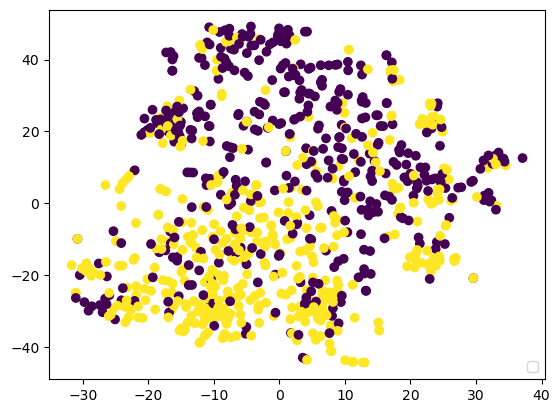

After Oversampling
Final_Ytrain
 0  
1.0    431
0.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8771929824561403
Training MCC Score: 0.7543668602004198
Training F1 Score: 0.8771822299684935
Training AUC VALUE: 0.9558836405025608
Training kappa Score: 0.7543647959811864
Training Precision: 0.8773148148148148
Training Recall: 0.8793503480278422
Training Sensitivity: 0.8793503480278422
Training Specificity: 0.875
Training CCR: 0.8771929824561403
Training PPV: 0.8773148148148148


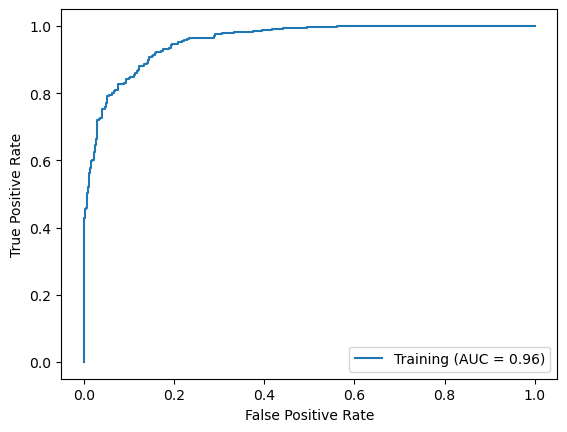

Testing Accuracy: 0.6244131455399061
Testing MCC Score: 0.24907463718258682
Testing F1 Score: 0.6225412014885698
Testing AUC VALUE: 0.6326164874551972
Testing kappa Score: 0.24748277689454168
Testing Precision: 0.5619047619047619
Testing Recall: 0.6344086021505376
Testing Sensitivity: 0.6344086021505376
Testing Specificity: 0.6166666666666667
Testing CCR: 0.6244131455399061
Testing PPV: 0.5619047619047619


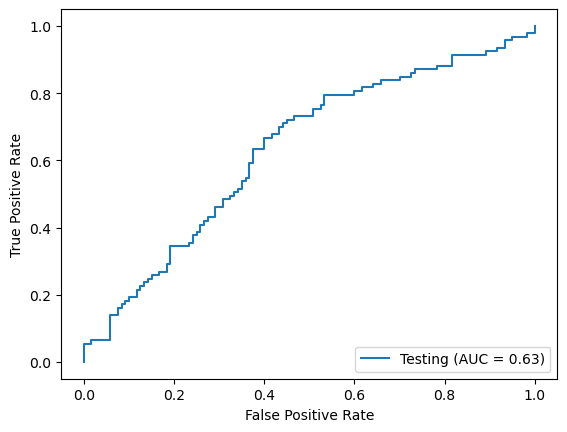

Fold # 1 Random Seed: 579
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:43:15,033:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:43:15,034:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:43:15,035:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 46
After filteration
Train shape
 (849, 46) 
Test shape
 (213, 46)
Before Oversampling
y_train_filtered
 0.0    426
1.0    423
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


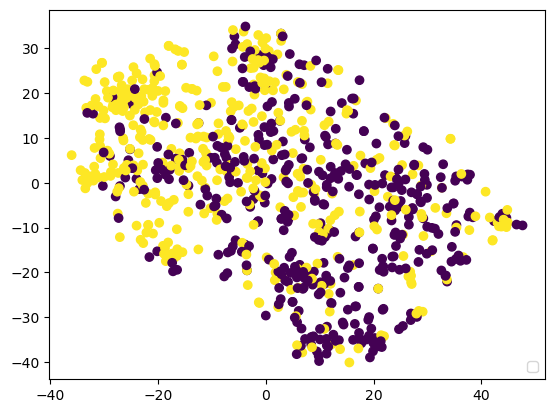

After Oversampling
Final_Ytrain
 0  
0.0    426
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.92
Training MCC Score: 0.8407377107591731
Training F1 Score: 0.9199556848081983
Training AUC VALUE: 0.975958344406059
Training kappa Score: 0.8399831677795865
Training Precision: 0.9384236453201971
Training Recall: 0.8985849056603774
Training Sensitivity: 0.8985849056603774
Training Specificity: 0.9413145539906104
Training CCR: 0.92
Training PPV: 0.9384236453201971


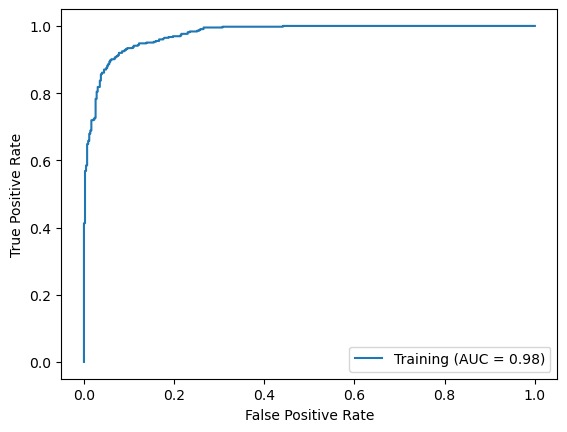

Testing Accuracy: 0.6807511737089202
Testing MCC Score: 0.36223215305896256
Testing F1 Score: 0.6805751587861679
Testing AUC VALUE: 0.734087694483734
Testing kappa Score: 0.3616571176729837
Testing Precision: 0.6542056074766355
Testing Recall: 0.693069306930693
Testing Sensitivity: 0.693069306930693
Testing Specificity: 0.6696428571428571
Testing CCR: 0.6807511737089202
Testing PPV: 0.6542056074766355


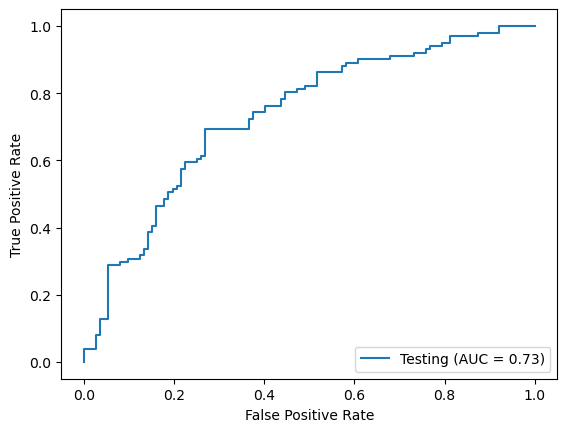

Fold # 2 Random Seed: 903
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:43:39,053:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:43:39,055:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:43:39,055:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 44
After filteration
Train shape
 (849, 44) 
Test shape
 (213, 44)
Before Oversampling
y_train_filtered
 1.0    428
0.0    421
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


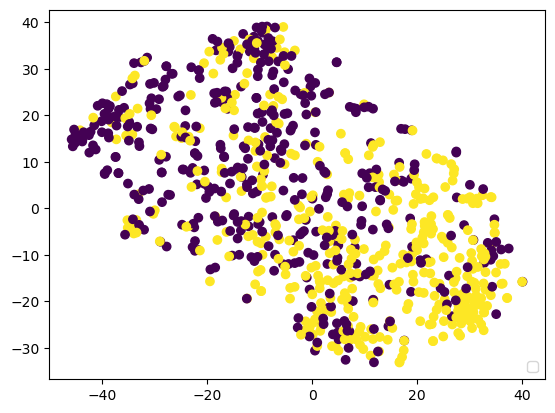

After Oversampling
Final_Ytrain
 0  
1.0    428
0.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9812206572769953
Training MCC Score: 0.9624404866866514
Training F1 Score: 0.9812202433433257
Training AUC VALUE: 0.99823388732146
Training kappa Score: 0.9624404866866514
Training Precision: 0.9813084112149533
Training Recall: 0.9813084112149533
Training Sensitivity: 0.9813084112149533
Training Specificity: 0.9811320754716981
Training CCR: 0.9812206572769953
Training PPV: 0.9813084112149533


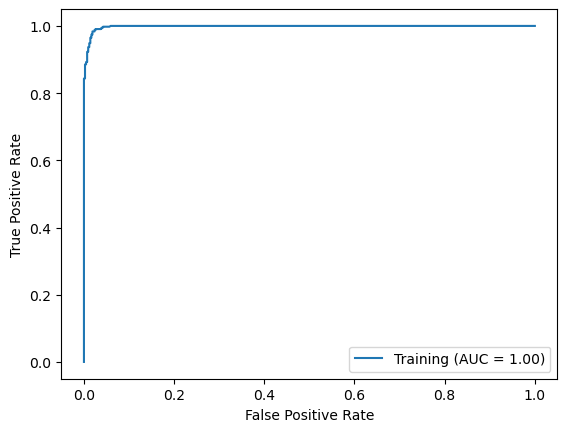

Testing Accuracy: 0.6572769953051644
Testing MCC Score: 0.3130071190238676
Testing F1 Score: 0.655789963031014
Testing AUC VALUE: 0.7200854700854701
Testing kappa Score: 0.31232585909513066
Testing Precision: 0.6116504854368932
Testing Recall: 0.65625
Testing Sensitivity: 0.65625
Testing Specificity: 0.6581196581196581
Testing CCR: 0.6572769953051644
Testing PPV: 0.6116504854368932


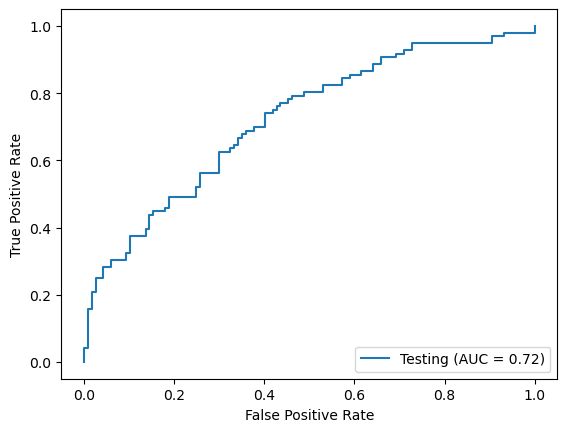

Fold # 3 Random Seed: 371
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:44:03,354:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:44:03,356:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:44:03,356:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 40
After filteration
Train shape
 (849, 40) 
Test shape
 (213, 40)
Before Oversampling
y_train_filtered
 0.0    427
1.0    422
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


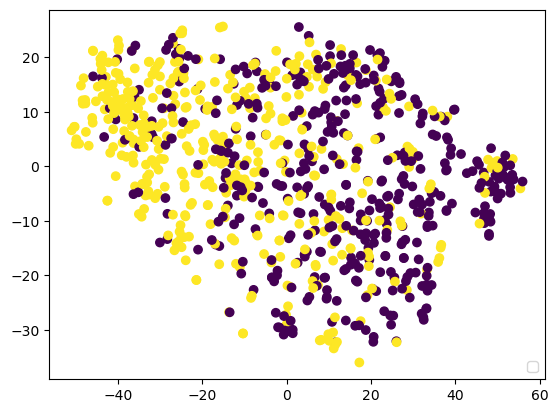

After Oversampling
Final_Ytrain
 0  
0.0    427
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8601645123384254
Training MCC Score: 0.7206319167147425
Training F1 Score: 0.8601150639896677
Training AUC VALUE: 0.9415652202730767
Training kappa Score: 0.7202954230963633
Training Precision: 0.8710462287104623
Training Recall: 0.8443396226415094
Training Sensitivity: 0.8443396226415094
Training Specificity: 0.8758782201405152
Training CCR: 0.8601645123384254
Training PPV: 0.8710462287104623


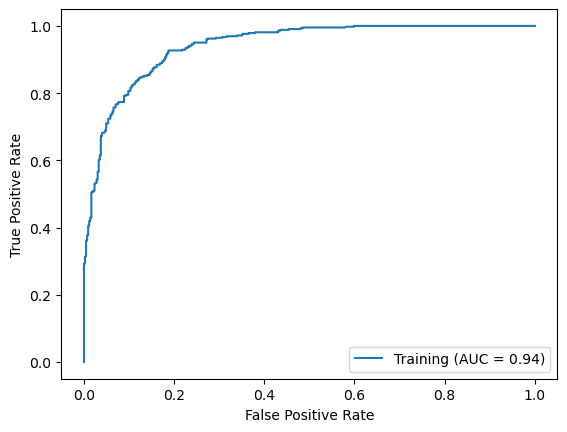

Testing Accuracy: 0.6525821596244131
Testing MCC Score: 0.311827037129689
Testing F1 Score: 0.652206531332745
Testing AUC VALUE: 0.6913089560148383
Testing kappa Score: 0.308320168509742
Testing Precision: 0.6186440677966102
Testing Recall: 0.7156862745098039
Testing Sensitivity: 0.7156862745098039
Testing Specificity: 0.5945945945945946
Testing CCR: 0.6525821596244131
Testing PPV: 0.6186440677966102


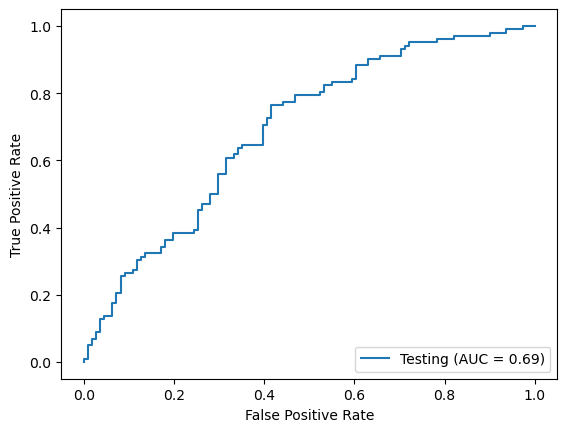

Fold # 4 Random Seed: 864
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:44:26,701:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:44:26,702:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:44:26,703:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 44
After filteration
Train shape
 (849, 44) 
Test shape
 (213, 44)
Before Oversampling
y_train_filtered
 0.0    447
1.0    402
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


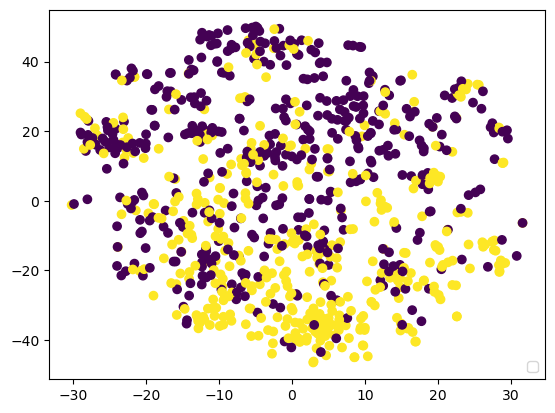

After Oversampling
Final_Ytrain
 0  
0.0    447
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.947187141216992
Training MCC Score: 0.8944239928245868
Training F1 Score: 0.9471670147899656
Training AUC VALUE: 0.9918692752522055
Training kappa Score: 0.8943390454490314
Training Precision: 0.9395348837209302
Training Recall: 0.9528301886792453
Training Sensitivity: 0.9528301886792453
Training Specificity: 0.941834451901566
Training CCR: 0.947187141216992
Training PPV: 0.9395348837209302


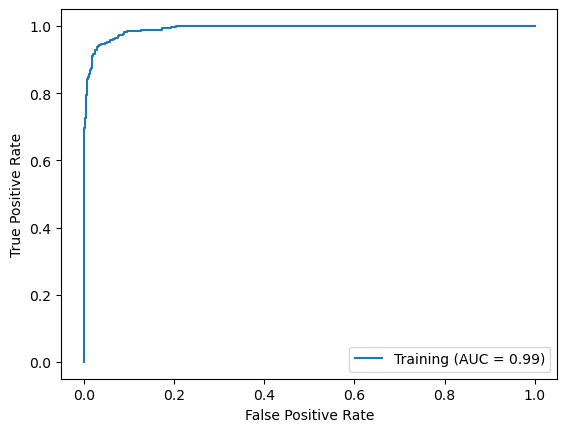

Testing Accuracy: 0.6244131455399061
Testing MCC Score: 0.2851530035865378
Testing F1 Score: 0.6242060691601976
Testing AUC VALUE: 0.7057286975319761
Testing kappa Score: 0.26929674099485423
Testing Precision: 0.7441860465116279
Testing Recall: 0.5245901639344263
Testing Sensitivity: 0.5245901639344263
Testing Specificity: 0.7582417582417582
Testing CCR: 0.6244131455399061
Testing PPV: 0.7441860465116279


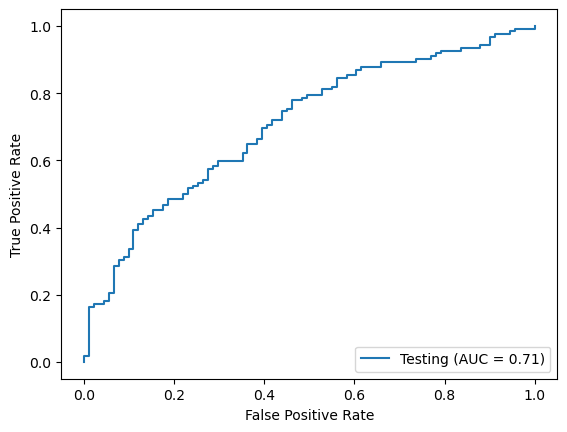

Fold # 5 Random Seed: 239
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:44:50,436:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:44:50,437:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:44:50,438:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 43
After filteration
Train shape
 (849, 43) 
Test shape
 (213, 43)
Before Oversampling
y_train_filtered
 1.0    429
0.0    420
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


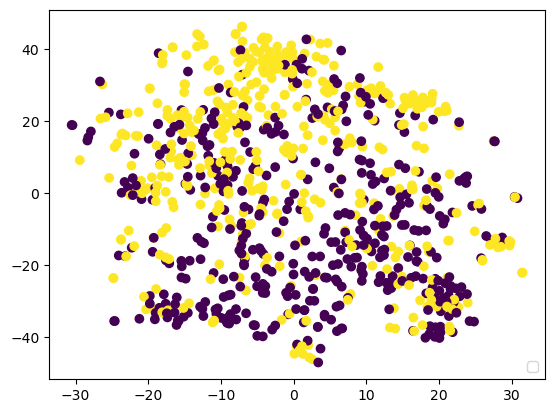

After Oversampling
Final_Ytrain
 0  
1.0    429
0.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8264947245017585
Training MCC Score: 0.6530253219231664
Training F1 Score: 0.8264944860419348
Training AUC VALUE: 0.900998372696486
Training kappa Score: 0.6529966026409244
Training Precision: 0.8305882352941176
Training Recall: 0.8228438228438228
Training Sensitivity: 0.8228438228438228
Training Specificity: 0.8301886792452831
Training CCR: 0.8264947245017585
Training PPV: 0.8305882352941176


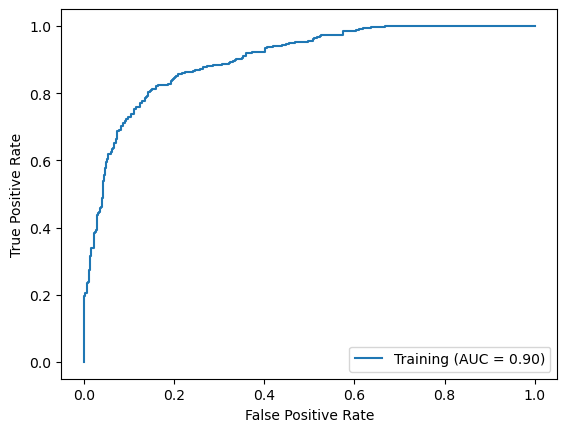

Testing Accuracy: 0.704225352112676
Testing MCC Score: 0.40662671707688736
Testing F1 Score: 0.7025469376898011
Testing AUC VALUE: 0.7693131132917038
Testing kappa Score: 0.4057393383818254
Testing Precision: 0.6568627450980392
Testing Recall: 0.7052631578947368
Testing Sensitivity: 0.7052631578947368
Testing Specificity: 0.7033898305084746
Testing CCR: 0.704225352112676
Testing PPV: 0.6568627450980392


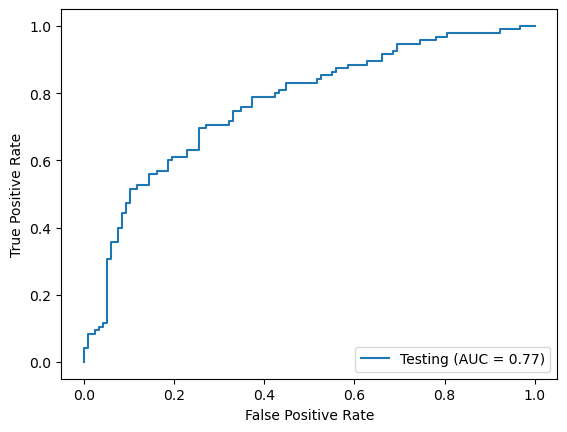

Fold # 6 Random Seed: 567
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:45:13,347:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:45:13,348:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:45:13,349:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 37
After filteration
Train shape
 (849, 37) 
Test shape
 (213, 37)
Before Oversampling
y_train_filtered
 0.0    429
1.0    420
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


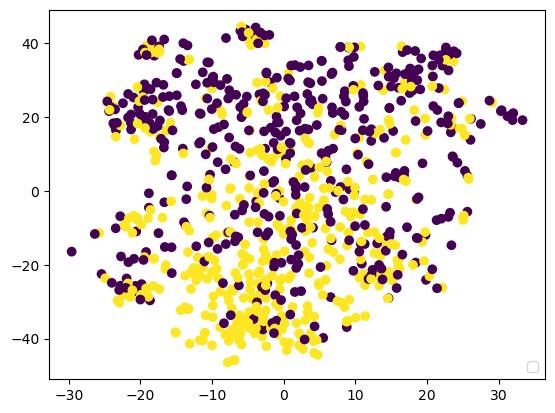

After Oversampling
Final_Ytrain
 0  
0.0    429
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8464243845252052
Training MCC Score: 0.6929020167860245
Training F1 Score: 0.8463939845903239
Training AUC VALUE: 0.9212599507410828
Training kappa Score: 0.6928086607268039
Training Precision: 0.8513189448441247
Training Recall: 0.8372641509433962
Training Sensitivity: 0.8372641509433962
Training Specificity: 0.8554778554778555
Training CCR: 0.8464243845252052
Training PPV: 0.8513189448441247


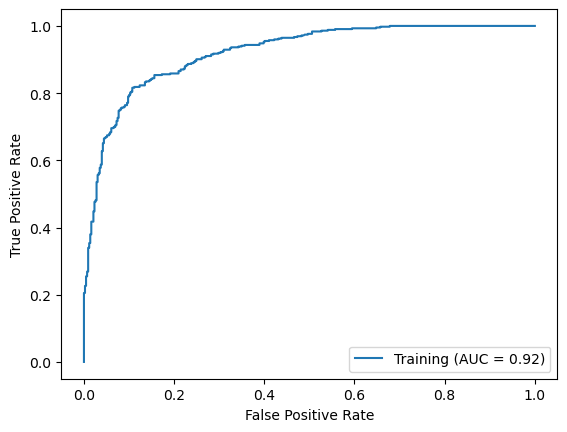

Testing Accuracy: 0.7323943661971831
Testing MCC Score: 0.4664662260426232
Testing F1 Score: 0.7304695304695306
Testing AUC VALUE: 0.7844036697247706
Testing kappa Score: 0.4629539523156545
Testing Precision: 0.7582417582417582
Testing Recall: 0.6634615384615384
Testing Sensitivity: 0.6634615384615384
Testing Specificity: 0.7981651376146789
Testing CCR: 0.7323943661971831
Testing PPV: 0.7582417582417582


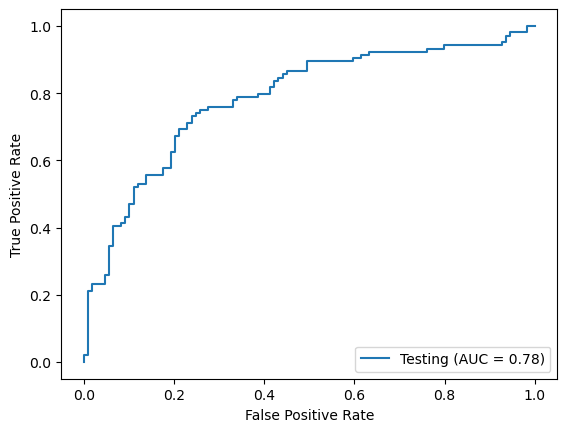

Fold # 7 Random Seed: 163
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:45:36,360:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:45:36,362:INFO:MSMOTE: returning copies for Sampling is not needed
INFO:smote_variants:MSMOTE: returning copies for Sampling is not needed


# of Features selected: 48
After filteration
Train shape
 (849, 48) 
Test shape
 (213, 48)
Before Oversampling
y_train_filtered
 0.0    425
1.0    424
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


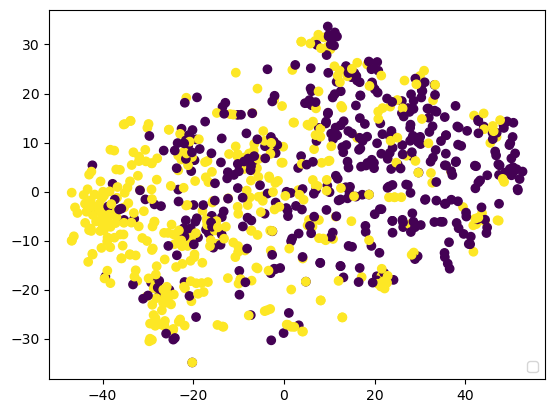

After Oversampling
Final_Ytrain
 0  
0.0    425
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.928150765606596
Training MCC Score: 0.8564149915819387
Training F1 Score: 0.9281443855386917
Training AUC VALUE: 0.9828884572697003
Training kappa Score: 0.8562985407596707
Training Precision: 0.935251798561151
Training Recall: 0.9198113207547169
Training Sensitivity: 0.9198113207547169
Training Specificity: 0.9364705882352942
Training CCR: 0.928150765606596
Training PPV: 0.935251798561151


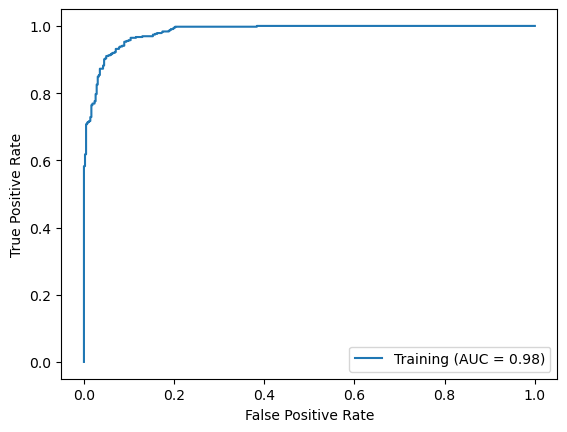

Testing Accuracy: 0.6619718309859155
Testing MCC Score: 0.3232023878913936
Testing F1 Score: 0.6613672496025438
Testing AUC VALUE: 0.6891150442477876
Testing kappa Score: 0.322973688857496
Testing Precision: 0.6346153846153846
Testing Recall: 0.66
Testing Sensitivity: 0.66
Testing Specificity: 0.6637168141592921
Testing CCR: 0.6619718309859155
Testing PPV: 0.6346153846153846


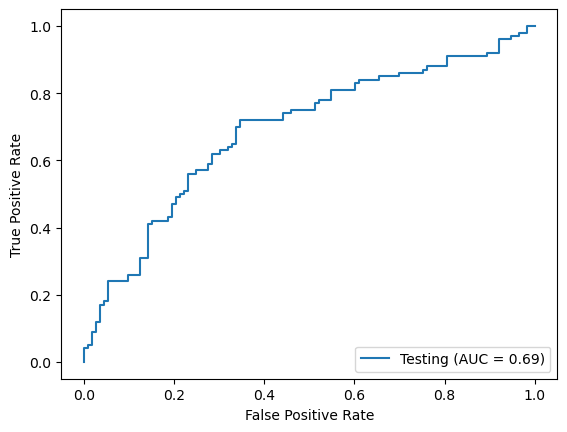

Fold # 8 Random Seed: 350
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:46:00,529:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:46:00,530:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:46:00,531:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 45
After filteration
Train shape
 (849, 45) 
Test shape
 (213, 45)
Before Oversampling
y_train_filtered
 0.0    426
1.0    423
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


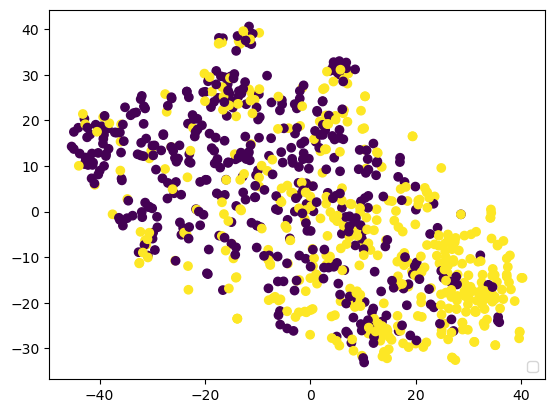

After Oversampling
Final_Ytrain
 0  
0.0    426
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9658823529411765
Training MCC Score: 0.931786410129167
Training F1 Score: 0.9658811723589051
Training AUC VALUE: 0.9966366595801223
Training kappa Score: 0.93176319475587
Training Precision: 0.9691211401425178
Training Recall: 0.9622641509433962
Training Sensitivity: 0.9622641509433962
Training Specificity: 0.9694835680751174
Training CCR: 0.9658823529411765
Training PPV: 0.9691211401425178


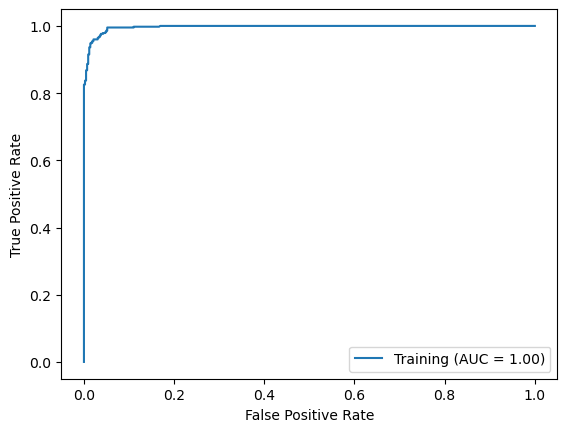

Testing Accuracy: 0.7089201877934272
Testing MCC Score: 0.4186460808690228
Testing F1 Score: 0.7087597035991531
Testing AUC VALUE: 0.7317008486562941
Testing kappa Score: 0.4179814896430145
Testing Precision: 0.6822429906542056
Testing Recall: 0.7227722772277227
Testing Sensitivity: 0.7227722772277227
Testing Specificity: 0.6964285714285714
Testing CCR: 0.7089201877934272
Testing PPV: 0.6822429906542056


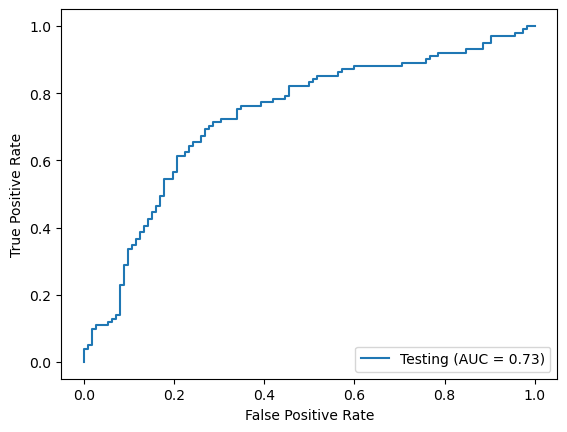

Fold # 9 Random Seed: 170
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:46:23,786:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:46:23,787:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:46:23,788:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 43
After filteration
Train shape
 (849, 43) 
Test shape
 (213, 43)
Before Oversampling
y_train_filtered
 0.0    436
1.0    413
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


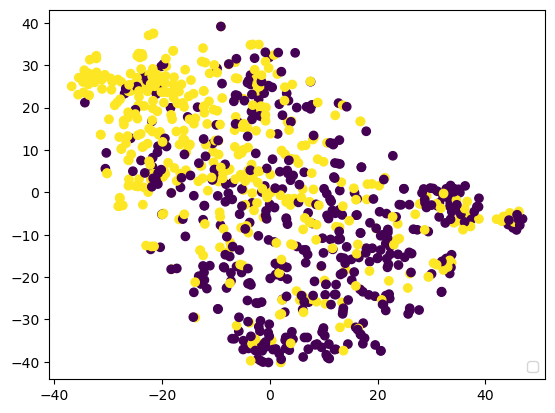

After Oversampling
Final_Ytrain
 0  
0.0    436
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9709302325581395
Training MCC Score: 0.9419608559135204
Training F1 Score: 0.9709160366268554
Training AUC VALUE: 0.9983663666262766
Training kappa Score: 0.9418359286232159
Training Precision: 0.9784172661870504
Training Recall: 0.9622641509433962
Training Sensitivity: 0.9622641509433962
Training Specificity: 0.9793577981651376
Training CCR: 0.9709302325581395
Training PPV: 0.9784172661870504


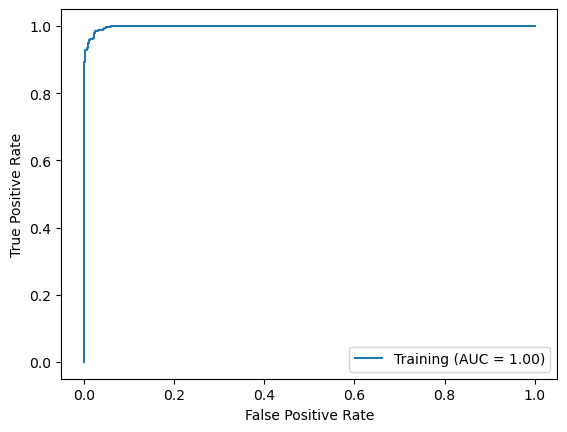

Testing Accuracy: 0.6525821596244131
Testing MCC Score: 0.30918298221595136
Testing F1 Score: 0.6525132275132275
Testing AUC VALUE: 0.6891008655714539
Testing kappa Score: 0.3072257383966245
Testing Precision: 0.6868686868686869
Testing Recall: 0.6126126126126126
Testing Sensitivity: 0.6126126126126126
Testing Specificity: 0.696078431372549
Testing CCR: 0.6525821596244131
Testing PPV: 0.6868686868686869


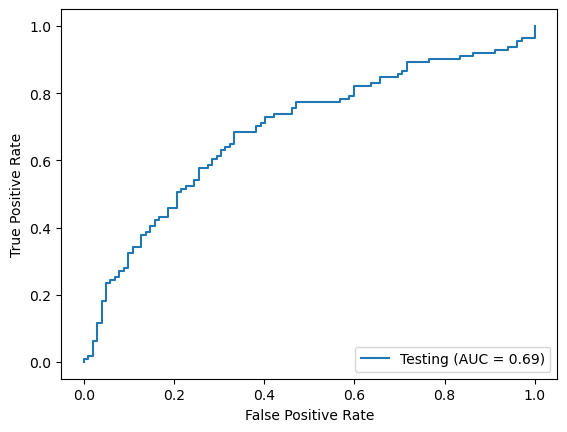

Fold # 10 Random Seed: 396
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:46:46,891:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:46:46,892:INFO:MSMOTE: returning copies for Sampling is not needed
INFO:smote_variants:MSMOTE: returning copies for Sampling is not needed


# of Features selected: 43
After filteration
Train shape
 (849, 43) 
Test shape
 (213, 43)
Before Oversampling
y_train_filtered
 1.0    425
0.0    424
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


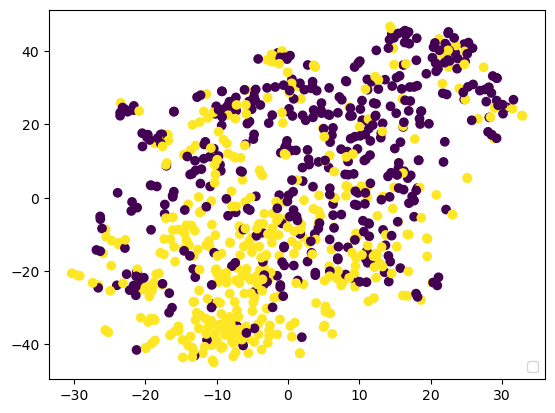

After Oversampling
Final_Ytrain
 0  
1.0    425
0.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8315665488810365
Training MCC Score: 0.6632901266938505
Training F1 Score: 0.8315515923284083
Training AUC VALUE: 0.916367924528302
Training kappa Score: 0.6631410425377835
Training Precision: 0.8389423076923077
Training Recall: 0.8211764705882353
Training Sensitivity: 0.8211764705882353
Training Specificity: 0.8419811320754716
Training CCR: 0.8315665488810365
Training PPV: 0.8389423076923077


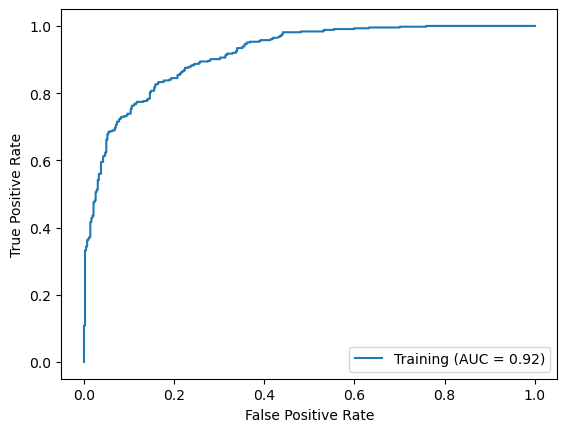

Testing Accuracy: 0.6431924882629108
Testing MCC Score: 0.29034007085343416
Testing F1 Score: 0.6431216931216932
Testing AUC VALUE: 0.6788942052099947
Testing kappa Score: 0.2885021097046413
Testing Precision: 0.6036036036036037
Testing Recall: 0.6767676767676768
Testing Sensitivity: 0.6767676767676768
Testing Specificity: 0.6140350877192983
Testing CCR: 0.6431924882629108
Testing PPV: 0.6036036036036037


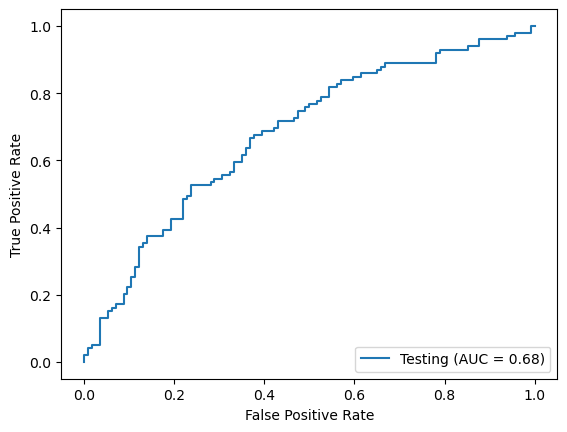

Fold # 11 Random Seed: 830
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:47:10,365:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:47:10,366:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:47:10,367:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 40
After filteration
Train shape
 (849, 40) 
Test shape
 (213, 40)
Before Oversampling
y_train_filtered
 0.0    441
1.0    408
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


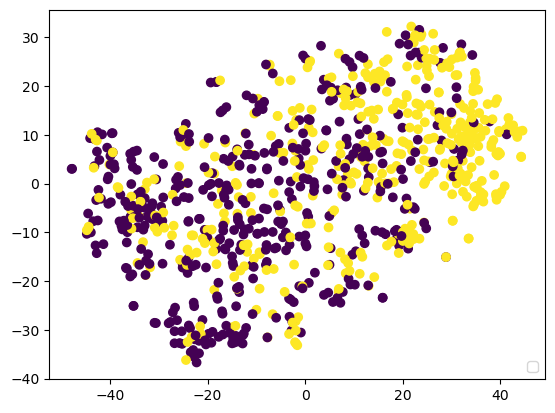

After Oversampling
Final_Ytrain
 0  
0.0    441
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9202312138728324
Training MCC Score: 0.8405177521242233
Training F1 Score: 0.920159079873025
Training AUC VALUE: 0.9810705728832413
Training kappa Score: 0.8403354600537699
Training Precision: 0.927710843373494
Training Recall: 0.9080188679245284
Training Sensitivity: 0.9080188679245284
Training Specificity: 0.9319727891156463
Training CCR: 0.9202312138728324
Training PPV: 0.927710843373494


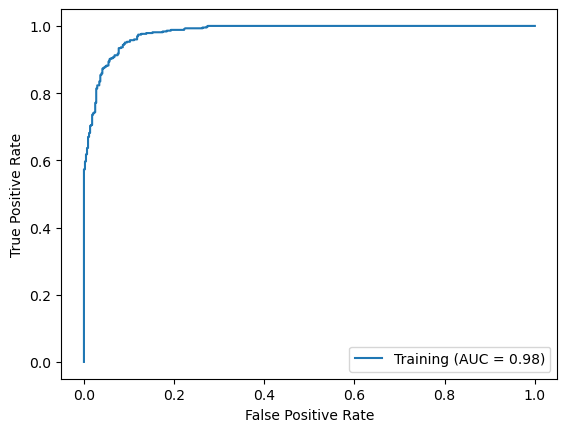

Testing Accuracy: 0.6666666666666666
Testing MCC Score: 0.3418230883953812
Testing F1 Score: 0.6666372754326022
Testing AUC VALUE: 0.7351581940988269
Testing kappa Score: 0.33749507162570636
Testing Precision: 0.7272727272727273
Testing Recall: 0.6206896551724138
Testing Sensitivity: 0.6206896551724138
Testing Specificity: 0.7216494845360825
Testing CCR: 0.6666666666666666
Testing PPV: 0.7272727272727273


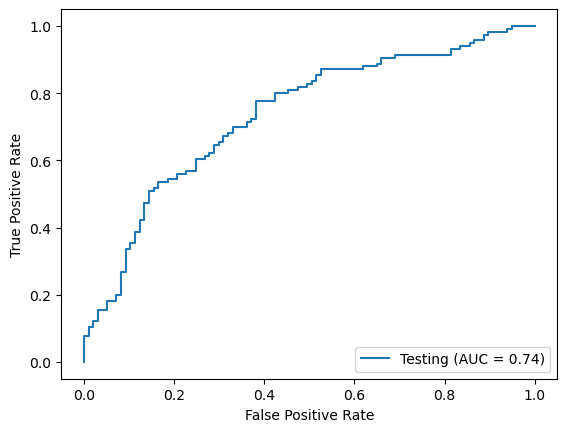

Fold # 12 Random Seed: 521
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:47:33,794:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:47:33,795:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:47:33,796:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 39
After filteration
Train shape
 (849, 39) 
Test shape
 (213, 39)
Before Oversampling
y_train_filtered
 0.0    444
1.0    405
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


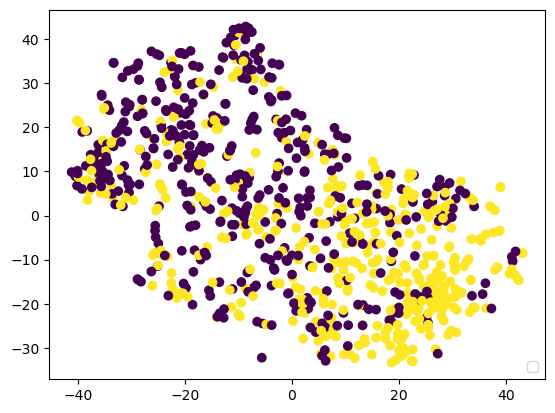

After Oversampling
Final_Ytrain
 0  
0.0    444
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9953917050691244
Training MCC Score: 0.9908187009303001
Training F1 Score: 0.9953881792871868
Training AUC VALUE: 0.9999229772225056
Training kappa Score: 0.9907765545968462
Training Precision: 1.0
Training Recall: 0.9905660377358491
Training Sensitivity: 0.9905660377358491
Training Specificity: 1.0
Training CCR: 0.9953917050691244
Training PPV: 1.0


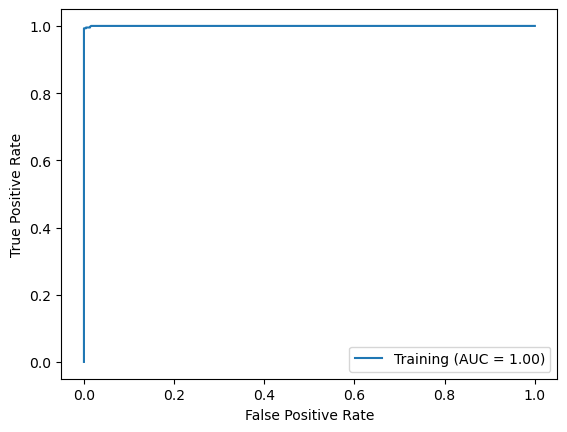

Testing Accuracy: 0.6854460093896714
Testing MCC Score: 0.37635147828832183
Testing F1 Score: 0.6847511542114914
Testing AUC VALUE: 0.743965671374933
Testing kappa Score: 0.3726205653492768
Testing Precision: 0.75
Testing Recall: 0.6554621848739496
Testing Sensitivity: 0.6554621848739496
Testing Specificity: 0.723404255319149
Testing CCR: 0.6854460093896714
Testing PPV: 0.75


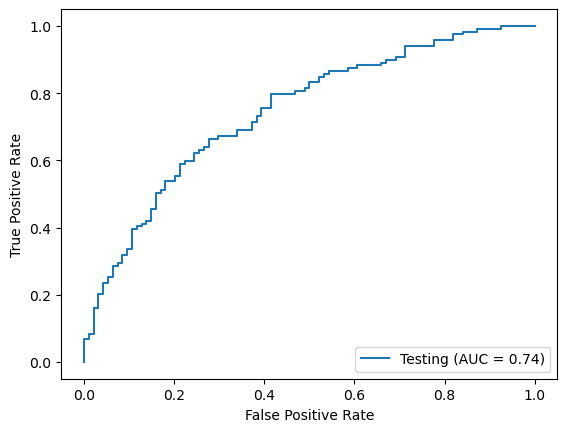

Fold # 13 Random Seed: 897
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:47:57,498:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:47:57,500:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:47:57,500:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 48
After filteration
Train shape
 (849, 48) 
Test shape
 (213, 48)
Before Oversampling
y_train_filtered
 0.0    427
1.0    422
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


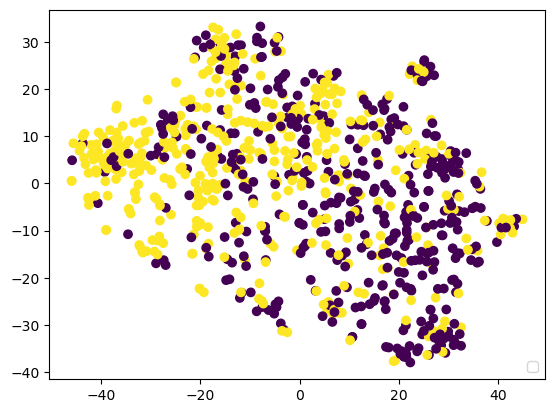

After Oversampling
Final_Ytrain
 0  
0.0    427
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8754406580493537
Training MCC Score: 0.7509944753501555
Training F1 Score: 0.8754198431112583
Training AUC VALUE: 0.9553626662542531
Training kappa Score: 0.7508617070637884
Training Precision: 0.8822115384615384
Training Recall: 0.8655660377358491
Training Sensitivity: 0.8655660377358491
Training Specificity: 0.8852459016393442
Training CCR: 0.8754406580493537
Training PPV: 0.8822115384615384


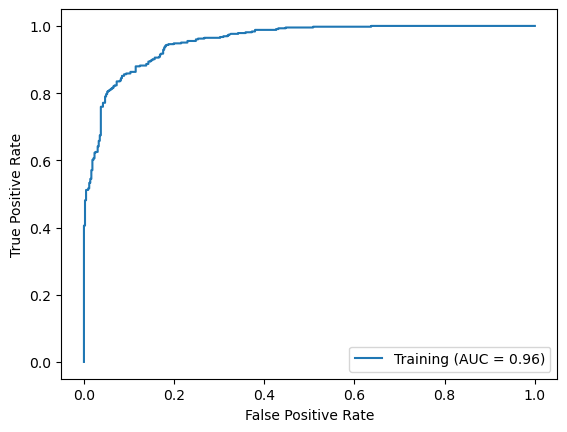

Testing Accuracy: 0.6384976525821596
Testing MCC Score: 0.2774445132513386
Testing F1 Score: 0.6383701188455009
Testing AUC VALUE: 0.7044691750574104
Testing kappa Score: 0.27713870157344966
Testing Precision: 0.616822429906542
Testing Recall: 0.6470588235294118
Testing Sensitivity: 0.6470588235294118
Testing Specificity: 0.6306306306306306
Testing CCR: 0.6384976525821596
Testing PPV: 0.616822429906542


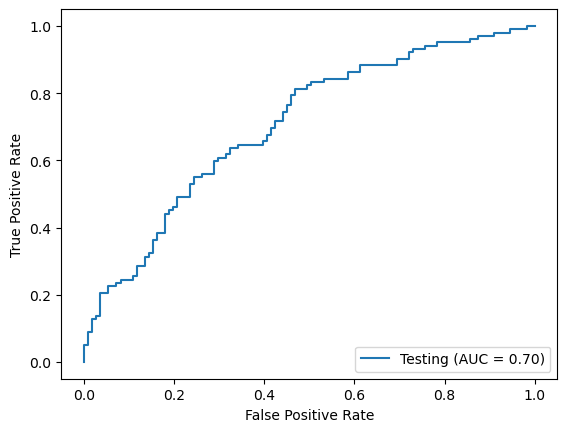

Fold # 14 Random Seed: 682
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:48:20,679:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:48:20,680:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:48:20,681:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 43
After filteration
Train shape
 (849, 43) 
Test shape
 (213, 43)
Before Oversampling
y_train_filtered
 0.0    428
1.0    421
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


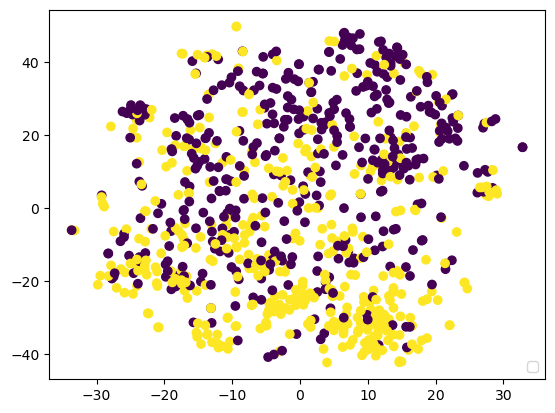

After Oversampling
Final_Ytrain
 0  
0.0    428
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8884976525821596
Training MCC Score: 0.7771417635961057
Training F1 Score: 0.8884716873238856
Training AUC VALUE: 0.9583544568859108
Training kappa Score: 0.7769682674396817
Training Precision: 0.8963855421686747
Training Recall: 0.8773584905660378
Training Sensitivity: 0.8773584905660378
Training Specificity: 0.8995327102803738
Training CCR: 0.8884976525821596
Training PPV: 0.8963855421686747


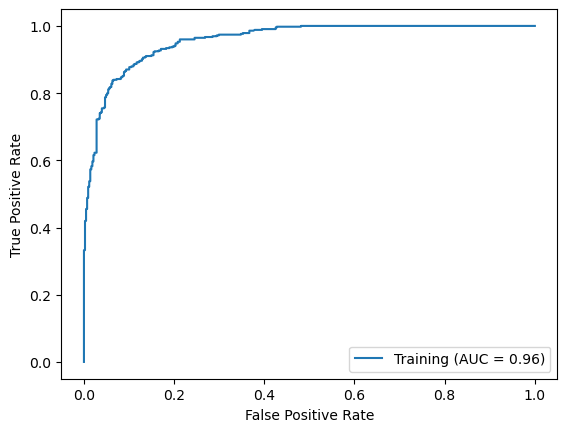

Testing Accuracy: 0.6948356807511737
Testing MCC Score: 0.38849694434907206
Testing F1 Score: 0.6938640132669983
Testing AUC VALUE: 0.7330097087378641
Testing kappa Score: 0.38806629834254147
Testing Precision: 0.6938775510204082
Testing Recall: 0.6601941747572816
Testing Sensitivity: 0.6601941747572816
Testing Specificity: 0.7272727272727273
Testing CCR: 0.6948356807511737
Testing PPV: 0.6938775510204082


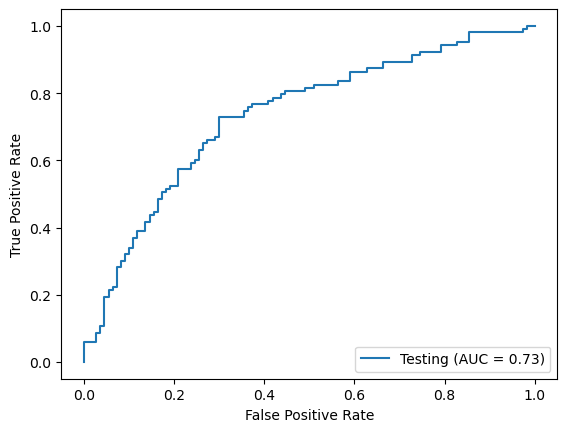

Fold # 15 Random Seed: 678
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:48:44,320:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:48:44,322:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:48:44,322:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 42
After filteration
Train shape
 (849, 42) 
Test shape
 (213, 42)
Before Oversampling
y_train_filtered
 1.0    427
0.0    422
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


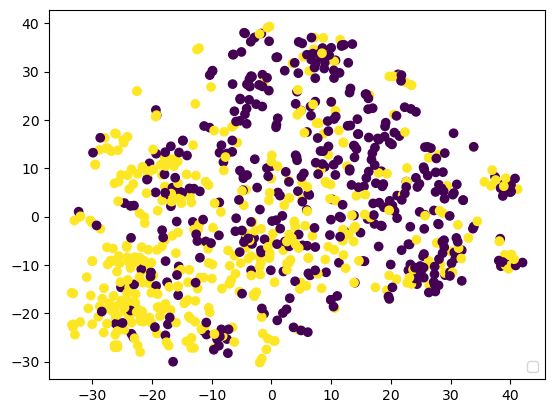

After Oversampling
Final_Ytrain
 0  
1.0    427
0.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9447708578143361
Training MCC Score: 0.889847764462994
Training F1 Score: 0.9447659766038747
Training AUC VALUE: 0.9903036763731166
Training kappa Score: 0.8895504088322117
Training Precision: 0.9567307692307693
Training Recall: 0.9320843091334895
Training Sensitivity: 0.9320843091334895
Training Specificity: 0.9575471698113207
Training CCR: 0.9447708578143361
Training PPV: 0.9567307692307693


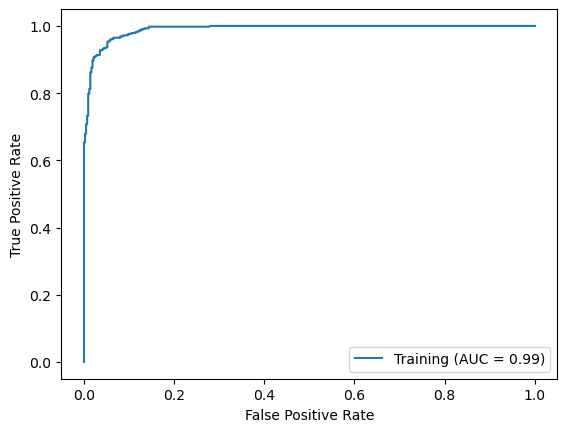

Testing Accuracy: 0.647887323943662
Testing MCC Score: 0.30616779239246356
Testing F1 Score: 0.6478873239436621
Testing AUC VALUE: 0.7420902950586562
Testing kappa Score: 0.30133391646621477
Testing Precision: 0.5948275862068966
Testing Recall: 0.711340206185567
Testing Sensitivity: 0.711340206185567
Testing Specificity: 0.5948275862068966
Testing CCR: 0.647887323943662
Testing PPV: 0.5948275862068966


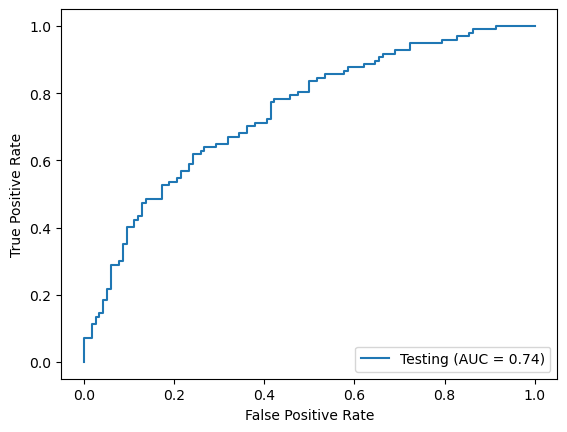

Fold # 16 Random Seed: 422
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:49:07,776:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:49:07,777:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:49:07,778:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 40
After filteration
Train shape
 (849, 40) 
Test shape
 (213, 40)
Before Oversampling
y_train_filtered
 0.0    430
1.0    419
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


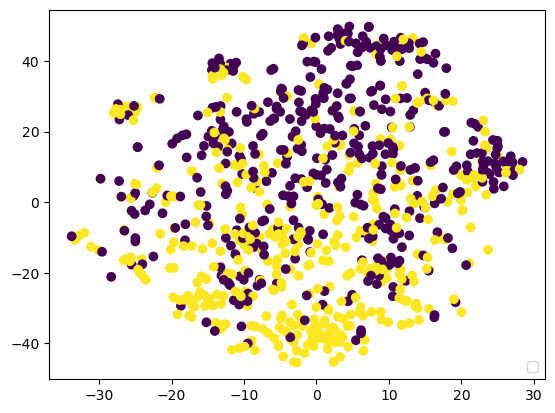

After Oversampling
Final_Ytrain
 0  
0.0    430
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9988290398126464
Training MCC Score: 0.9976606617257179
Training F1 Score: 0.9988289611349478
Training AUC VALUE: 0.9999286967968407
Training kappa Score: 0.9976579254814416
Training Precision: 1.0
Training Recall: 0.9976415094339622
Training Sensitivity: 0.9976415094339622
Training Specificity: 1.0
Training CCR: 0.9988290398126464
Training PPV: 1.0


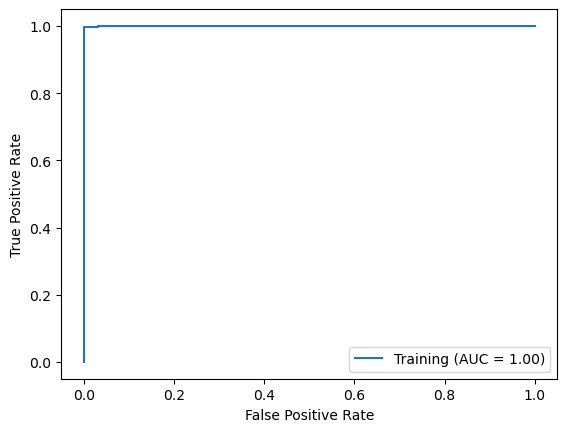

Testing Accuracy: 0.6901408450704225
Testing MCC Score: 0.380061792600281
Testing F1 Score: 0.689970007057163
Testing AUC VALUE: 0.7179894179894181
Testing kappa Score: 0.37999470759460174
Testing Precision: 0.6893203883495146
Testing Recall: 0.6761904761904762
Testing Sensitivity: 0.6761904761904762
Testing Specificity: 0.7037037037037037
Testing CCR: 0.6901408450704225
Testing PPV: 0.6893203883495146


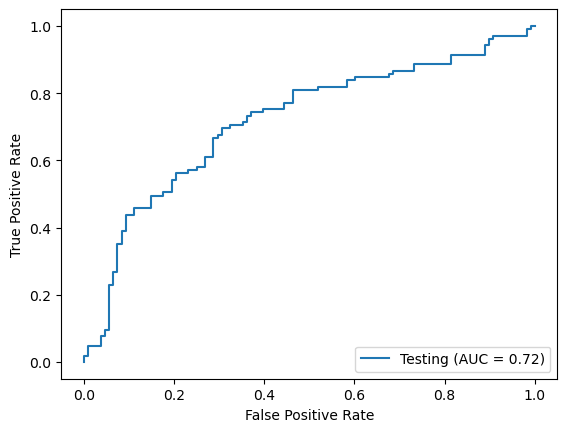

Fold # 17 Random Seed: 849
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:49:31,592:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:49:31,593:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:49:31,594:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 38
After filteration
Train shape
 (849, 38) 
Test shape
 (213, 38)
Before Oversampling
y_train_filtered
 1.0    432
0.0    417
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


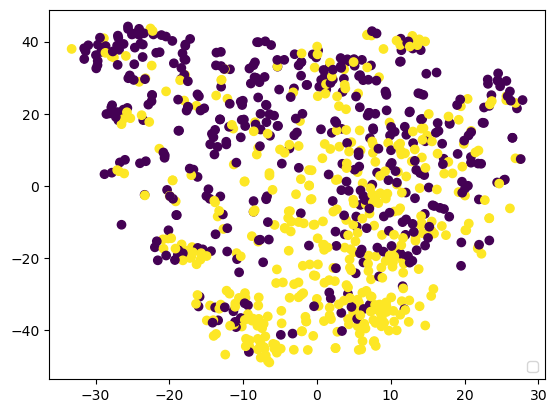

After Oversampling
Final_Ytrain
 0  
1.0    432
0.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9509345794392523
Training MCC Score: 0.9018661496969772
Training F1 Score: 0.9509278823317446
Training AUC VALUE: 0.9893158193570929
Training kappa Score: 0.901856300502293
Training Precision: 0.9493087557603687
Training Recall: 0.9537037037037037
Training Sensitivity: 0.9537037037037037
Training Specificity: 0.9481132075471698
Training CCR: 0.9509345794392523
Training PPV: 0.9493087557603687


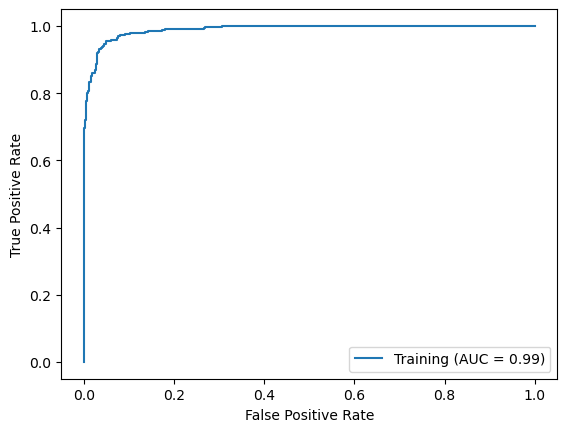

Testing Accuracy: 0.7089201877934272
Testing MCC Score: 0.41021694303958817
Testing F1 Score: 0.7048542821383873
Testing AUC VALUE: 0.7517067912324829
Testing kappa Score: 0.4099195710455764
Testing Precision: 0.65625
Testing Recall: 0.6847826086956522
Testing Sensitivity: 0.6847826086956522
Testing Specificity: 0.7272727272727273
Testing CCR: 0.7089201877934272
Testing PPV: 0.65625


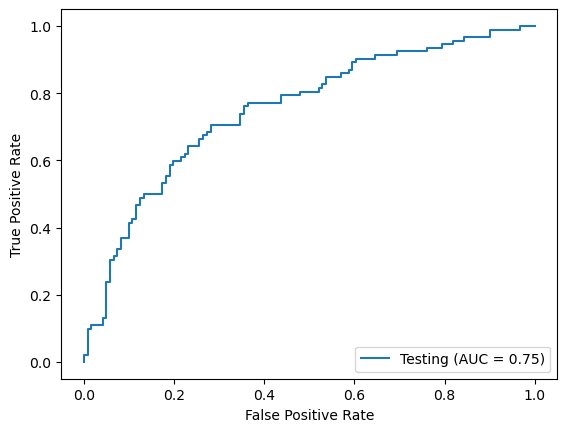

Fold # 18 Random Seed: 306
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:49:55,255:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:49:55,256:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:49:55,256:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 43
After filteration
Train shape
 (849, 43) 
Test shape
 (213, 43)
Before Oversampling
y_train_filtered
 0.0    433
1.0    416
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


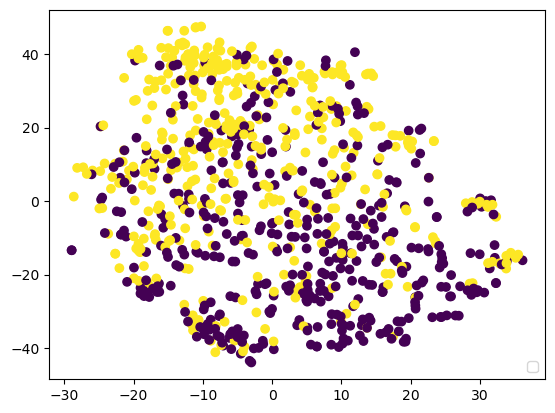

After Oversampling
Final_Ytrain
 0  
0.0    433
1.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8646441073512252
Training MCC Score: 0.7292900675193906
Training F1 Score: 0.8646026280808037
Training AUC VALUE: 0.9442976818162011
Training kappa Score: 0.7292185329447335
Training Precision: 0.868421052631579
Training Recall: 0.8561320754716981
Training Sensitivity: 0.8561320754716981
Training Specificity: 0.8729792147806005
Training CCR: 0.8646441073512252
Training PPV: 0.868421052631579


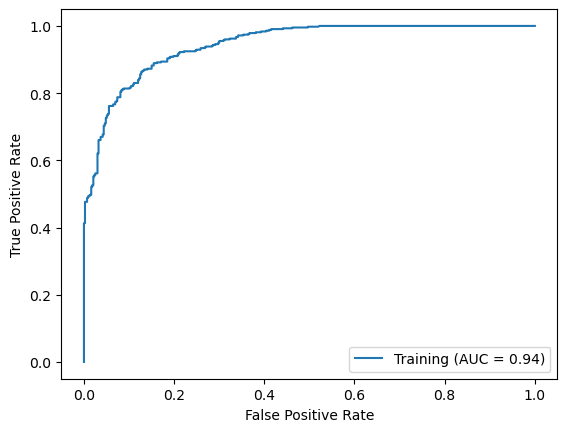

Testing Accuracy: 0.6619718309859155
Testing MCC Score: 0.32368027553378653
Testing F1 Score: 0.6616063548102382
Testing AUC VALUE: 0.7362433862433863
Testing kappa Score: 0.3234515616728427
Testing Precision: 0.6607142857142857
Testing Recall: 0.6851851851851852
Testing Sensitivity: 0.6851851851851852
Testing Specificity: 0.638095238095238
Testing CCR: 0.6619718309859155
Testing PPV: 0.6607142857142857


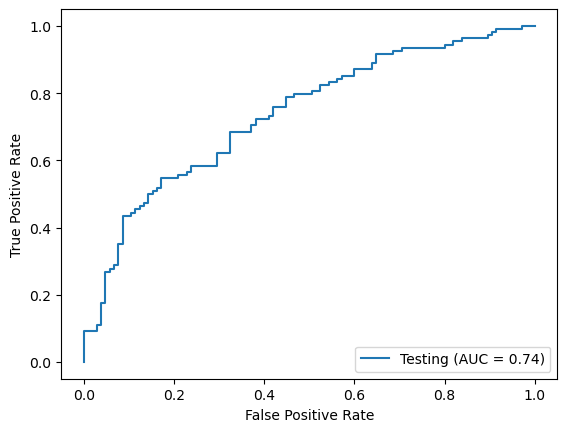

Fold # 19 Random Seed: 42
Before filteration
Train shape
 (849, 3200) 
Test shape
 (213, 3200)


2024-11-04 22:50:18,953:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:50:18,954:INFO:MSMOTE: returning copies for Sampling is not needed
INFO:smote_variants:MSMOTE: returning copies for Sampling is not needed


# of Features selected: 52
After filteration
Train shape
 (849, 52) 
Test shape
 (213, 52)
Before Oversampling
y_train_filtered
 1.0    425
0.0    424
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


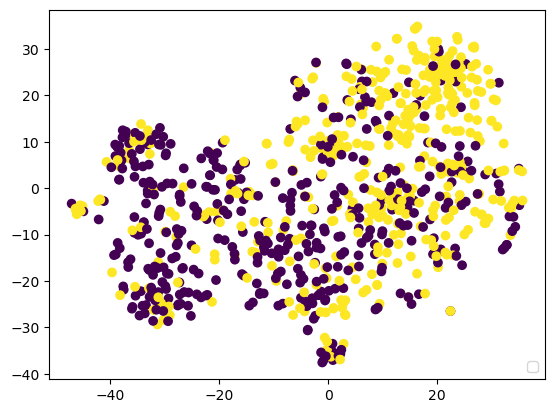

After Oversampling
Final_Ytrain
 0  
1.0    425
0.0    424
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8798586572438163
Training MCC Score: 0.7601397902089616
Training F1 Score: 0.8798304821323506
Training AUC VALUE: 0.951958934517203
Training kappa Score: 0.7597263147380513
Training Precision: 0.8929440389294404
Training Recall: 0.8635294117647059
Training Sensitivity: 0.8635294117647059
Training Specificity: 0.8962264150943396
Training CCR: 0.8798586572438163
Training PPV: 0.8929440389294404


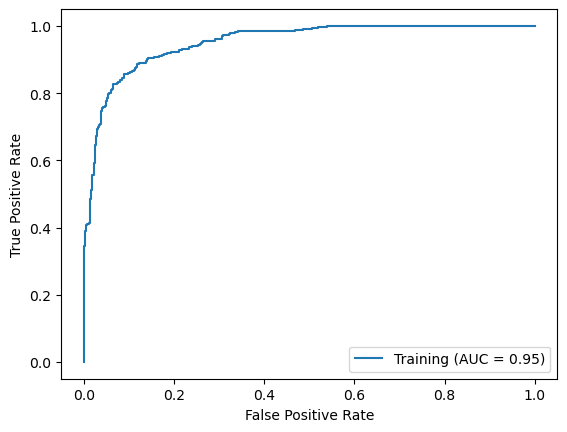

Testing Accuracy: 0.6995305164319249
Testing MCC Score: 0.3947390947772701
Testing F1 Score: 0.697120511908994
Testing AUC VALUE: 0.7130072656388445
Testing kappa Score: 0.394456289978678
Testing Precision: 0.6842105263157895
Testing Recall: 0.6565656565656566
Testing Sensitivity: 0.6565656565656566
Testing Specificity: 0.7368421052631579
Testing CCR: 0.6995305164319249
Testing PPV: 0.6842105263157895


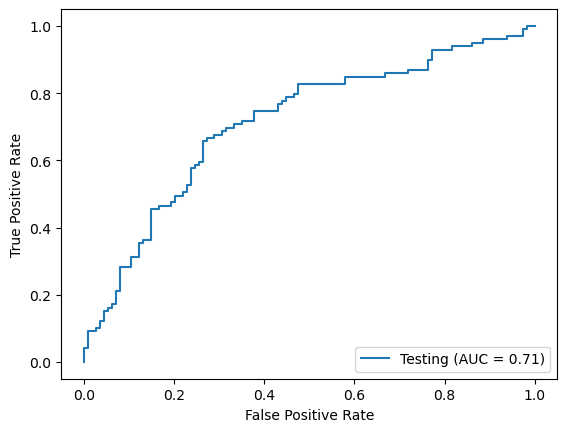

In [26]:
Train_Fold_outs=[]
Test_Fold_outs=[]
Best_params=[]
features = []
models=[]

#this chunk runs 20 iterations of the 5-Cross Validation of the pre-defined grid for the model
for i in range(20):
    #print('Fold #',i)   
    seed = random.randint(0, 1000)
    print('Fold #', i, "Random Seed:", seed)
    
    # Split Data
    X_train, X_test,y_train,y_test = train_test_split(Train,Train["status"] ,test_size=0.20, shuffle = True, random_state=seed)
    
    #Drop smiles,status from training,testing data
    x_train = X_train.drop(['status','smiles'], axis=1)
    x_test = X_test.drop(['status','smiles'], axis=1)

    #Feature selection
    x_train_filtered,x_test_filtered,y_train_filtered,y_test_filtered,selected_features = Boruta_Filteration(x_train,y_train,x_test,y_test)
    features.append(selected_features)
    
    y_train_filtered = pd.Series(y_train_filtered)

    print('Before Oversampling\ny_train_filtered\n',y_train_filtered.value_counts())
    #Oversampling
    Final_Xtrain,Final_Ytrain = Smote(x_train_filtered,y_train_filtered,0.5)
    print('After Oversampling\nFinal_Ytrain\n',Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)
    
    #Hyperparameter Tuning
    Parameters = HPTing_Model(Final_Xtrain,Final_Ytrain)
    
    #save best parameters
    Best_params.append(Parameters.best_estimator_.get_params())
    
    #build the tuned model
    #edit the parameters here according to your defined parameter space and model's grid
    rf = RandomForestClassifier(max_features=Parameters.best_estimator_.get_params()['max_features'],
                        max_depth=Parameters.best_estimator_.get_params()['max_depth'],
                        min_samples_split=Parameters.best_estimator_.get_params()['min_samples_split'],
                        min_samples_leaf=Parameters.best_estimator_.get_params()['min_samples_leaf'],
                        bootstrap=Parameters.best_estimator_.get_params()['bootstrap'],
                        n_estimators=Parameters.best_estimator_.get_params()['n_estimators'])

    
    #fit the built model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models.append(rf)

    #Training Predictions for the model
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)

    #Save training metrics
    Train_Fold_outs.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain,'Training'))

    #Testing Predictions for the model
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)

    #Save testing metrics
    Test_Fold_outs.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered,'Testing'))

In [28]:
#Analyse the testing metrics sorted by descending Testing Accuracy
pd.DataFrame.from_dict(Test_Fold_outs).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
6,0.732394,0.466466,0.730470,0.784404,0.462954,0.758242,0.663462,0.663462,0.798165,0.732394,0.758242
8,0.708920,0.418646,0.708760,0.731701,0.417981,0.682243,0.722772,0.722772,0.696429,0.708920,0.682243
17,0.708920,0.410217,0.704854,0.751707,0.409920,0.656250,0.684783,0.684783,0.727273,0.708920,0.656250
5,0.704225,0.406627,0.702547,0.769313,0.405739,0.656863,0.705263,0.705263,0.703390,0.704225,0.656863
19,0.699531,0.394739,0.697121,0.713007,0.394456,0.684211,0.656566,0.656566,0.736842,0.699531,0.684211
14,0.694836,0.388497,0.693864,0.733010,0.388066,0.693878,0.660194,0.660194,0.727273,0.694836,0.693878
16,0.690141,0.380062,0.689970,0.717989,0.379995,0.689320,0.676190,0.676190,0.703704,0.690141,0.689320
12,0.685446,0.376351,0.684751,0.743966,0.372621,0.750000,0.655462,0.655462,0.723404,0.685446,0.750000
1,0.680751,0.362232,0.680575,0.734088,0.361657,0.654206,0.693069,0.693069,0.669643,0.680751,0.654206
11,0.666667,0.341823,0.666637,0.735158,0.337495,0.727273,0.620690,0.620690,0.721649,0.666667,0.727273


In [29]:
#View the best parameters
pd.DataFrame.from_dict(Best_params)

,bootstrap,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,max_samples,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,n_estimators,n_jobs,oob_score,random_state,verbose,warm_start
0,True,0.0,None,gini,100,None,None,None,0.0,12,27,0.0,56,None,False,None,0,False
1,True,0.0,None,gini,30,log2,None,None,0.0,4,19,0.0,100,None,False,None,0,False
2,True,0.0,None,gini,110,log2,None,None,0.0,3,7,0.0,89,None,False,None,0,False
3,False,0.0,None,gini,70,log2,None,None,0.0,19,22,0.0,56,None,False,None,0,False
4,True,0.0,None,gini,80,log2,None,None,0.0,1,19,0.0,89,None,False,None,0,False
5,True,0.0,None,gini,90,log2,None,None,0.0,17,8,0.0,56,None,False,None,0,False
6,True,0.0,None,gini,40,sqrt,None,None,0.0,13,22,0.0,67,None,False,None,0,False
7,True,0.0,None,gini,110,sqrt,None,None,0.0,2,21,0.0,89,None,False,None,0,False
8,True,0.0,None,gini,100,log2,None,None,0.0,4,8,0.0,100,None,False,None,0,False
9,False,0.0,None,gini,20,sqrt,None,None,0.0,6,3,0.0,12,None,False,None,0,False


In [30]:
#View length of the features selected for the top performing/most stable (selected) model (1st here)
len(features[6])

37

In [31]:
#Save the feature names
pd.DataFrame(features[6]).to_csv('AID_1208_features.csv',index=False)

In [32]:
#save the best parameters of the chosen model
with open('AID_1208_best_params_RF.csv', 'w') as f:  # You will need 'wb' mode in Python 2.x
    w = csv.DictWriter(f, Best_params[6].keys())
    w.writeheader()
    w.writerow(Best_params[6])

In [33]:
"""
#Randomly split the data into testing and validation for each fold
def Test_valid_split(Set3,frac,seed):
    Fraction=frac
    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))
    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]
    Valid=Set3.T[Valid_index].T
    print('Test set size:',len(Test),'\nValid set size:',len(Valid))
    return Test,Valid
"""

"\n#Randomly split the data into testing and validation for each fold\ndef Test_valid_split(Set3,frac,seed):\n    Fraction=frac\n    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))\n    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]\n    Valid=Set3.T[Valid_index].T\n    print('Test set size:',len(Test),'\nValid set size:',len(Valid))\n    return Test,Valid\n"

In [34]:
def Test_valid_split(Set3, frac, seed):
    Fraction = frac
    Test_1 = Set3[Set3['status'] == 1].sample(frac=Fraction, random_state=1)
    Test_0 = Set3[Set3['status'] == 0].sample(frac=Fraction, random_state=seed)
    
    # 使用 pd.concat 代替 append
    Test = pd.concat([Test_1, Test_0])
    
    Valid_index = [item for item in list(Set3.index) if item not in list(Test.index)]
    Valid = Set3.T[Valid_index].T
    print('Test set size:', len(Test), '\nValid set size:', len(Valid))
    
    return Test, Valid

In [35]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('AID_1208_features.csv')

# 假设第一列名为 'Features'
f_list = df['Features'].tolist()

# 输出 f_list 确认结果
print(f_list)

['B1_27', 'B1_31', 'B2_98', 'C1_13', 'C1_41', 'C1_95', 'C1_102', 'C1_103', 'D1_8', 'D1_64', 'D1_97', 'D1_105', 'E1_9', 'E1_10', 'E1_72', 'E1_83', 'E2_17', 'E2_115', 'E4_5', 'E4_6', 'E4_17', 'E4_22', 'E4_37', 'E4_60', 'E4_70', 'E4_74', 'E4_90', 'E4_93', 'E4_111', 'E4_113', 'E4_117', 'E4_118', 'E4_122', 'E4_125', 'E5_53', 'E5_108', 'E5_117']


In [36]:
''' 
#f_list=features[1] #feature list of the selected (hyperparameter tuned) model
Train_Fold_outs_1=[]
Test_Fold_outs_1=[]
models_1=[]

# 用于存储训练和测试集的预测结果和标签
total_metrics= []


Parameters = pd.DataFrame.from_dict(Best_params).iloc[3].to_dict()
print(Parameters)
for i in range(20):
    print('Fold #',i)
    
    #Train-test split randomly
    Trn,Tst = Test_valid_split(Data,0.9,i)
    Train_y, Test_y = Trn['status'],Tst['status']

    #Use selected feature list
    Train_x = Trn[f_list]
    Test_x = Tst[f_list]
    print(Trn[f_list].shape)
    
    x_train_filtered = Train_x.values
    x_test_filtered = Test_x.values
    y_train_filtered = Train_y.values.ravel()
    y_test_filtered = Test_y.values.ravel()

    print(Train_y.value_counts())
    #Upsampling
    Final_Xtrain,Final_Ytrain = Smote(Train_x,Train_y,0.5)
    print(Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)

    #Use the best parameters from the chosen model here

    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])


    
    #Fit the model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models_1.append(rf)
    
    #Training prediction and saving the metrics
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain.astype('int'),'Training'))

    #Testing prediction and saving the metrics
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered.astype('int'),'Testing'))
'''
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob[:, 1])
    all_labels.extend(Final_Ytrain.astype('int'))
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob[:, 1])
    all_labels.extend(y_test_filtered.astype('int'))

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob[:, 1])\n    all_labels.extend(Final_Ytrain.astype('int'))\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob[:, 1])\n    all_labels.extend(y_test_filtered.astype('int'))\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [37]:
y_train_prob

array([[0.31103557, 0.68896443],
       [0.79144321, 0.20855679],
       [0.547864  , 0.452136  ],
       ...,
       [0.54424429, 0.45575571],
       [0.5500119 , 0.4499881 ],
       [0.53202715, 0.46797285]])

2024-11-04 22:52:26,309:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:26,309:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:26,310:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 40, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 13, 'min_samples_split': 22, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 67, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Fold #1


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


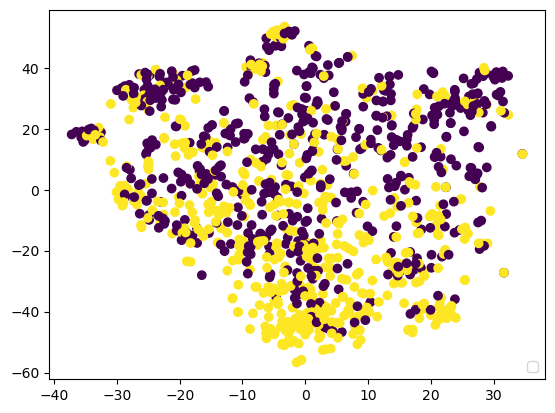

0  
0.0    546
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.8393686165273909
Training MCC Score: 0.6794214692352257
Training F1 Score: 0.8391000636445989
Training AUC VALUE: 0.9245980008691872
Training kappa Score: 0.6784336669445322
Training Precision: 0.8565737051792829
Training Recall: 0.8097928436911488
Training Sensitivity: 0.8097928436911488
Training Specificity: 0.8681318681318682
Training CCR: 0.8393686165273909
Training PPV: 0.8565737051792829


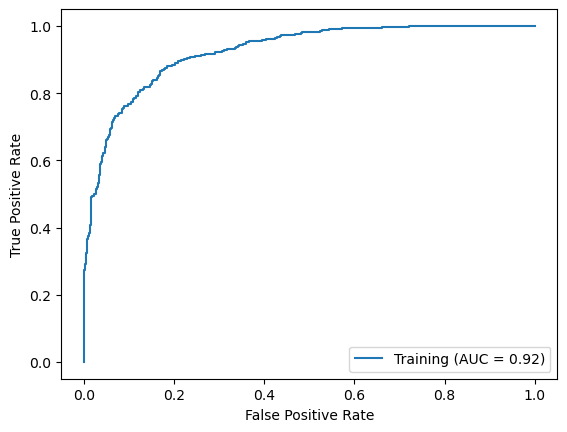

Testing Accuracy: 0.7033898305084746
Testing MCC Score: 0.4072254178140998
Testing F1 Score: 0.7023423423423423
Testing AUC VALUE: 0.7841954022988505
Testing kappa Score: 0.4057553956834533
Testing Precision: 0.7169811320754716
Testing Recall: 0.6551724137931034
Testing Sensitivity: 0.6551724137931034
Testing Specificity: 0.75
Testing CCR: 0.7033898305084746
Testing PPV: 0.7169811320754716


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


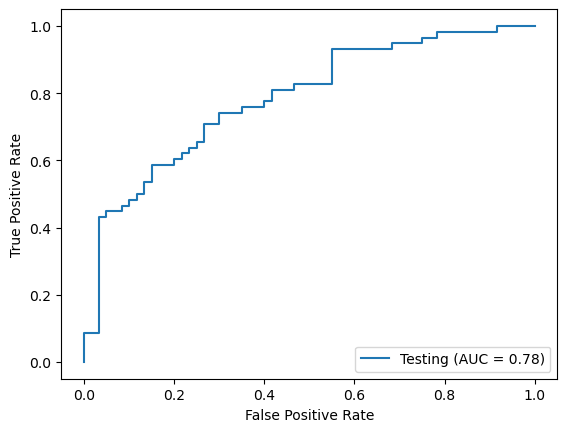

2024-11-04 22:52:29,245:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:29,245:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:29,246:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #2


C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


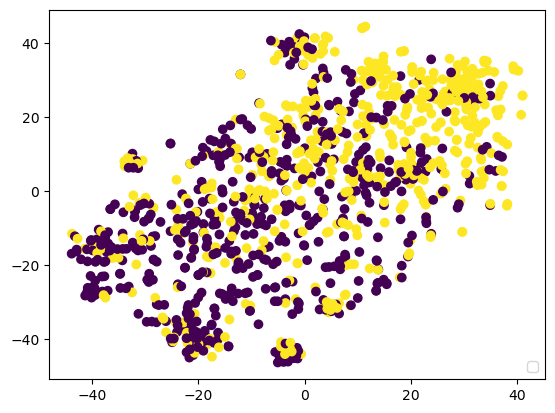

0  
0.0    546
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.8560817084493965
Training MCC Score: 0.7125874732325853
Training F1 Score: 0.8559023207033324
Training AUC VALUE: 0.9278591778591779
Training kappa Score: 0.7119361802359592
Training Precision: 0.8700787401574803
Training Recall: 0.832391713747646
Training Sensitivity: 0.832391713747646
Training Specificity: 0.8791208791208791
Training CCR: 0.8560817084493965
Training PPV: 0.8700787401574803


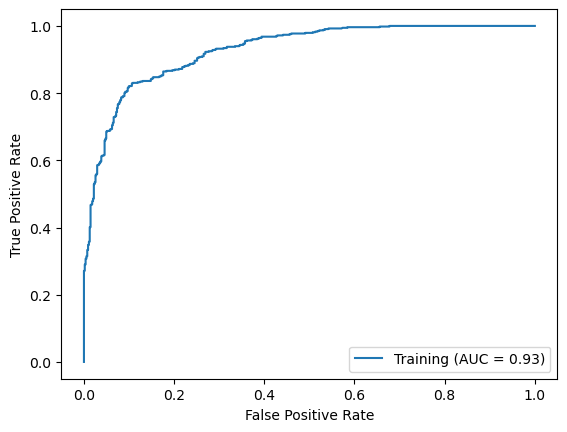

Testing Accuracy: 0.6440677966101694
Testing MCC Score: 0.2876871870285159
Testing F1 Score: 0.6436583261432269
Testing AUC VALUE: 0.7198275862068966
Testing kappa Score: 0.2875215641173088
Testing Precision: 0.6428571428571429
Testing Recall: 0.6206896551724138
Testing Sensitivity: 0.6206896551724138
Testing Specificity: 0.6666666666666666
Testing CCR: 0.6440677966101694
Testing PPV: 0.6428571428571429


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


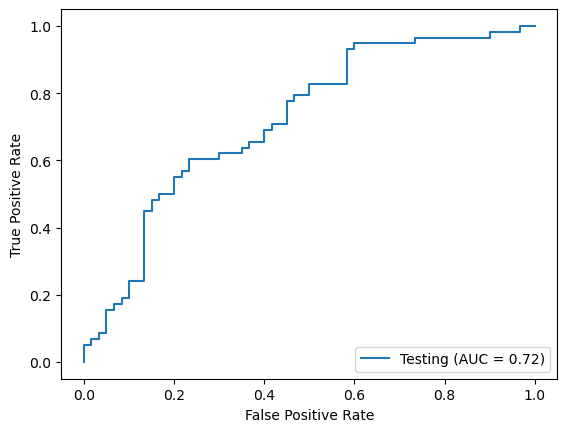

2024-11-04 22:52:32,118:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:32,119:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:32,120:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #3


C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


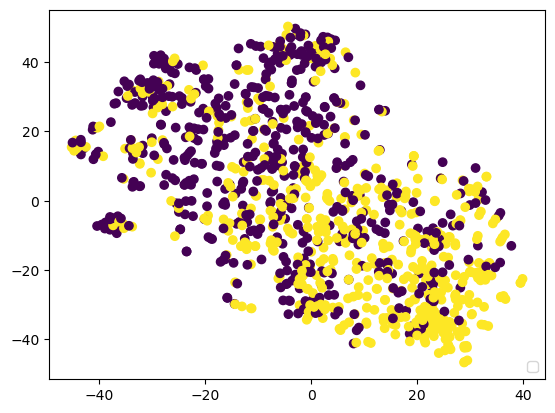

0  
0.0    546
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.8440111420612814
Training MCC Score: 0.6879731503047045
Training F1 Score: 0.8439399689494566
Training AUC VALUE: 0.9265881638762994
Training kappa Score: 0.6878971662768314
Training Precision: 0.847036328871893
Training Recall: 0.8342749529190208
Training Sensitivity: 0.8342749529190208
Training Specificity: 0.8534798534798534
Training CCR: 0.8440111420612814
Training PPV: 0.847036328871893


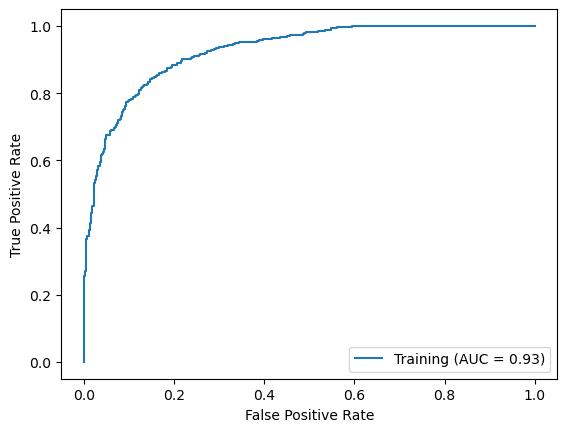

Testing Accuracy: 0.7033898305084746
Testing MCC Score: 0.4068381021724862
Testing F1 Score: 0.7033685268979386
Testing AUC VALUE: 0.7640804597701151
Testing kappa Score: 0.4067796610169492
Testing Precision: 0.6949152542372882
Testing Recall: 0.7068965517241379
Testing Sensitivity: 0.7068965517241379
Testing Specificity: 0.7
Testing CCR: 0.7033898305084746
Testing PPV: 0.6949152542372882


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


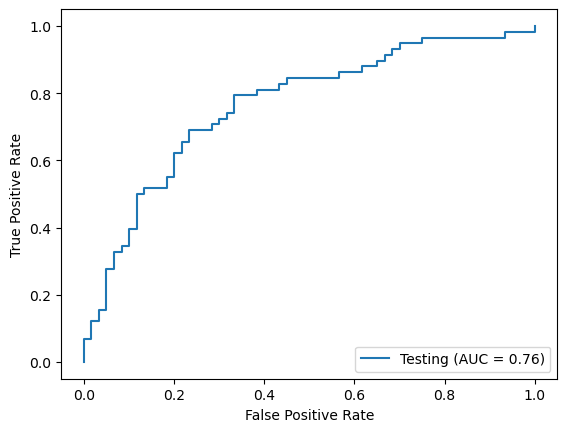

2024-11-04 22:52:35,071:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:35,072:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:35,073:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #4


C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


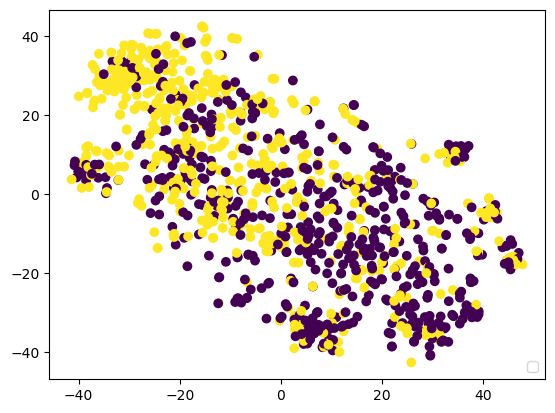

0  
0.0    546
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.8486536675951718
Training MCC Score: 0.6979163865868097
Training F1 Score: 0.8484231521415342
Training AUC VALUE: 0.9267140580699904
Training kappa Score: 0.6970370025213695
Training Precision: 0.8650793650793651
Training Recall: 0.8210922787193974
Training Sensitivity: 0.8210922787193974
Training Specificity: 0.8754578754578755
Training CCR: 0.8486536675951718
Training PPV: 0.8650793650793651


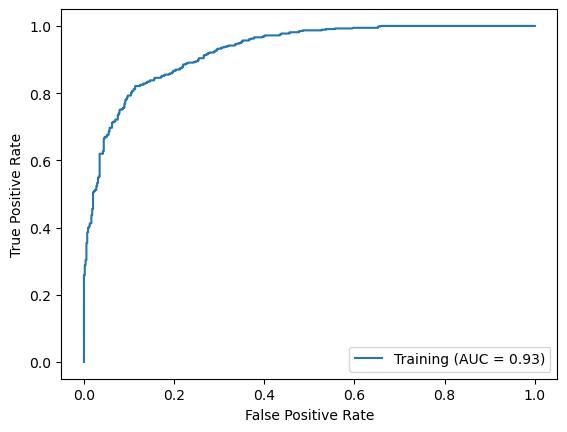

C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Testing Accuracy: 0.7203389830508474
Testing MCC Score: 0.4406057793017954
Testing F1 Score: 0.7198359594215411
Testing AUC VALUE: 0.7899425287356322
Testing kappa Score: 0.4400345125107852
Testing Precision: 0.7272727272727273
Testing Recall: 0.6896551724137931
Testing Sensitivity: 0.6896551724137931
Testing Specificity: 0.75
Testing CCR: 0.7203389830508474
Testing PPV: 0.7272727272727273


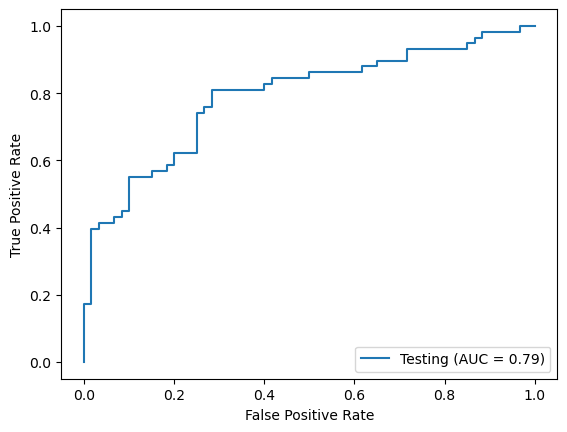

2024-11-04 22:52:38,030:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:38,031:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:38,032:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #5


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


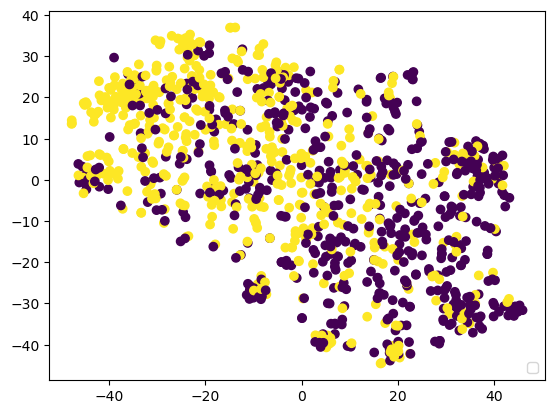

0  
0.0    545
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.8410780669144982
Training MCC Score: 0.6824615631722584
Training F1 Score: 0.8409097393889244
Training AUC VALUE: 0.9257571830888578
Training kappa Score: 0.6819407567208762
Training Precision: 0.8529411764705882
Training Recall: 0.8192090395480226
Training Sensitivity: 0.8192090395480226
Training Specificity: 0.8623853211009175
Training CCR: 0.8410780669144982
Training PPV: 0.8529411764705882


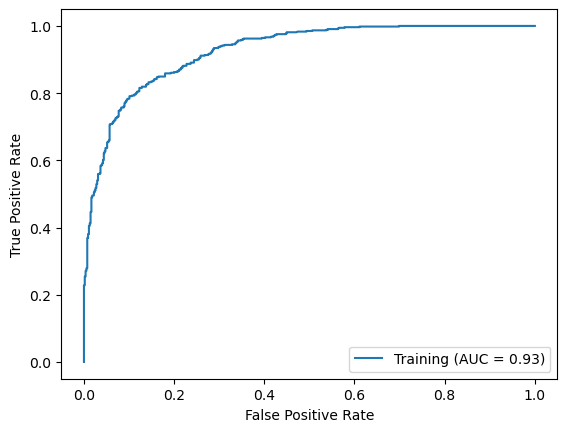

Testing Accuracy: 0.6779661016949152
Testing MCC Score: 0.35465336766690286
Testing F1 Score: 0.67713133640553
Testing AUC VALUE: 0.7653149266609146
Testing kappa Score: 0.35444860351281315
Testing Precision: 0.6727272727272727
Testing Recall: 0.6491228070175439
Testing Sensitivity: 0.6491228070175439
Testing Specificity: 0.7049180327868853
Testing CCR: 0.6779661016949152
Testing PPV: 0.6727272727272727


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


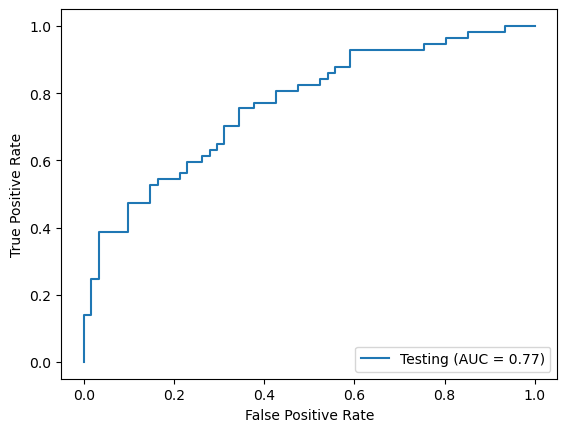

2024-11-04 22:52:40,956:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:40,957:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:40,958:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #6


C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


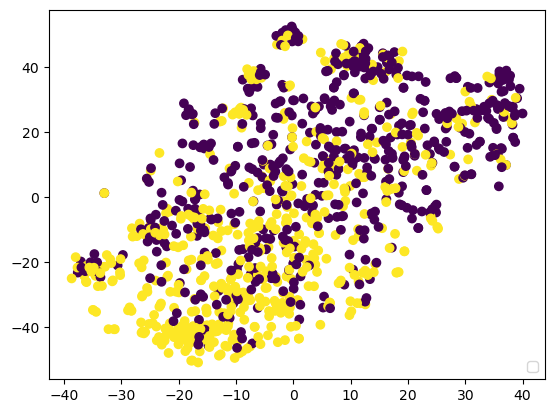

0  
0.0    545
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.8578066914498141
Training MCC Score: 0.7160625059743497
Training F1 Score: 0.857638357429521
Training AUC VALUE: 0.9294510962525269
Training kappa Score: 0.7154069023697076
Training Precision: 0.8720472440944882
Training Recall: 0.8342749529190208
Training Sensitivity: 0.8342749529190208
Training Specificity: 0.8807339449541285
Training CCR: 0.8578066914498141
Training PPV: 0.8720472440944882


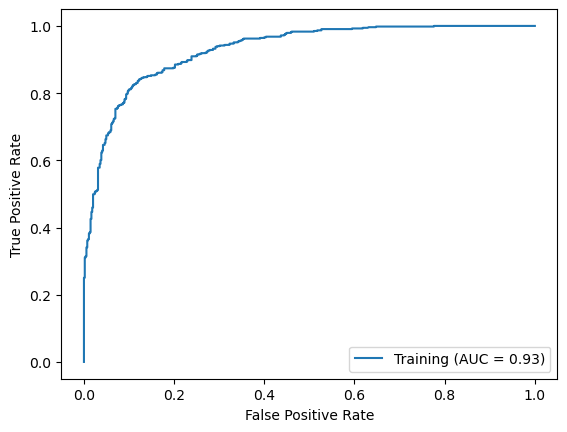

Testing Accuracy: 0.7203389830508474
Testing MCC Score: 0.4396385377871043
Testing F1 Score: 0.7193513513513513
Testing AUC VALUE: 0.7779695139488065
Testing kappa Score: 0.43906655142610196
Testing Precision: 0.7222222222222222
Testing Recall: 0.6842105263157895
Testing Sensitivity: 0.6842105263157895
Testing Specificity: 0.7540983606557377
Testing CCR: 0.7203389830508474
Testing PPV: 0.7222222222222222


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


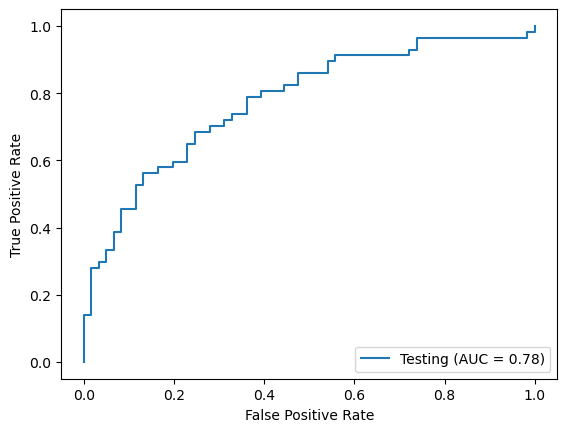

2024-11-04 22:52:44,281:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:44,282:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:44,283:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #7


C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


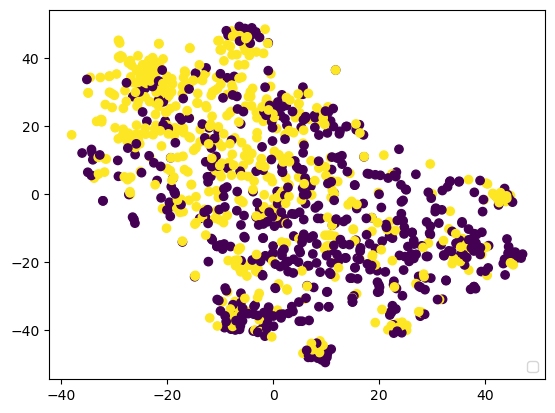

0  
0.0    545
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.8447955390334573
Training MCC Score: 0.6899974431723065
Training F1 Score: 0.844611801900196
Training AUC VALUE: 0.9302251248293854
Training kappa Score: 0.6893657038937331
Training Precision: 0.8582677165354331
Training Recall: 0.8210922787193974
Training Sensitivity: 0.8210922787193974
Training Specificity: 0.8678899082568807
Training CCR: 0.8447955390334573
Training PPV: 0.8582677165354331


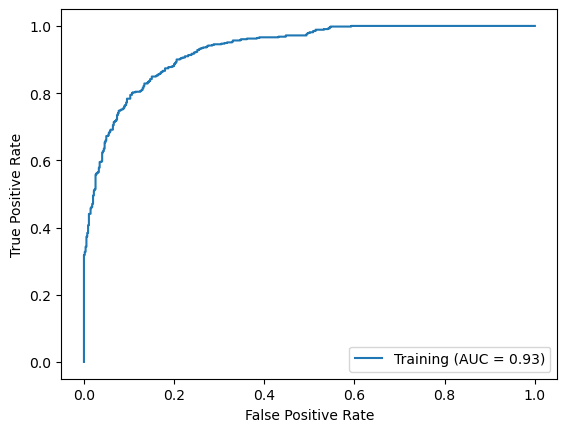

Testing Accuracy: 0.7203389830508474
Testing MCC Score: 0.44041976209241934
Testing F1 Score: 0.7201581027667985
Testing AUC VALUE: 0.7845844118492953
Testing kappa Score: 0.4403564242598448
Testing Precision: 0.7068965517241379
Testing Recall: 0.7192982456140351
Testing Sensitivity: 0.7192982456140351
Testing Specificity: 0.7213114754098361
Testing CCR: 0.7203389830508474
Testing PPV: 0.7068965517241379


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


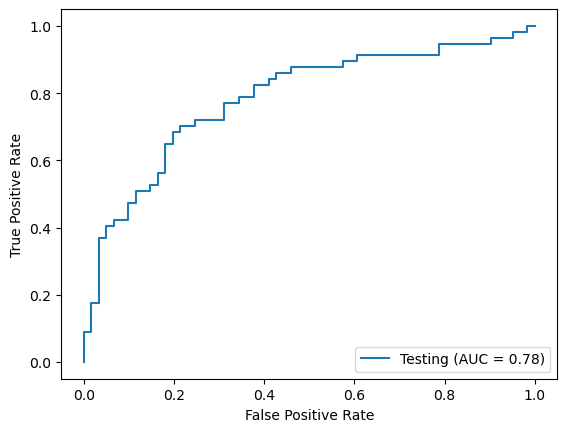

2024-11-04 22:52:47,150:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:47,151:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:47,152:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #8


C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


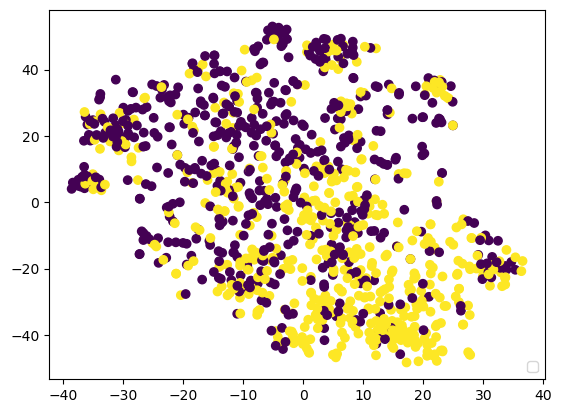

0  
0.0    545
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.845724907063197
Training MCC Score: 0.6914801568595231
Training F1 Score: 0.8456347765966641
Training AUC VALUE: 0.9279064945835276
Training kappa Score: 0.6913079696243833
Training Precision: 0.8516377649325626
Training Recall: 0.832391713747646
Training Sensitivity: 0.832391713747646
Training Specificity: 0.8587155963302753
Training CCR: 0.845724907063197
Training PPV: 0.8516377649325626


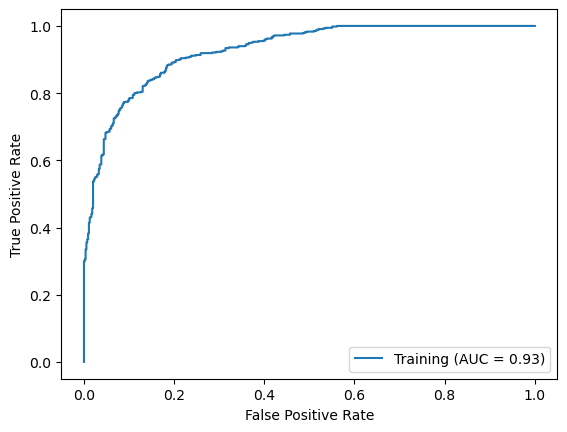

Testing Accuracy: 0.7203389830508474
Testing MCC Score: 0.44437931189642926
Testing F1 Score: 0.7157456748667788
Testing AUC VALUE: 0.813920046016681
Testing kappa Score: 0.43646888567293785
Testing Precision: 0.7608695652173914
Testing Recall: 0.6140350877192983
Testing Sensitivity: 0.6140350877192983
Testing Specificity: 0.819672131147541
Testing CCR: 0.7203389830508474
Testing PPV: 0.7608695652173914


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


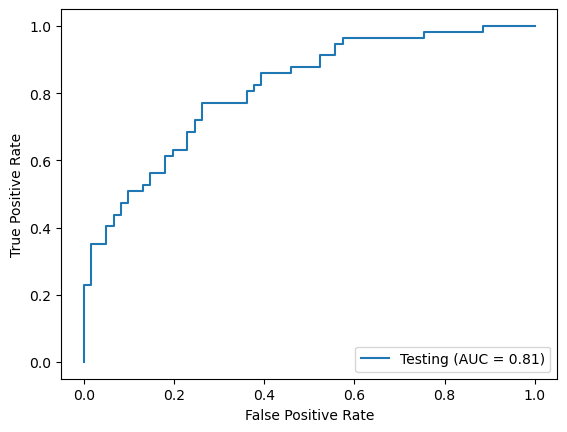

2024-11-04 22:52:50,018:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:50,019:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:50,019:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #9


C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


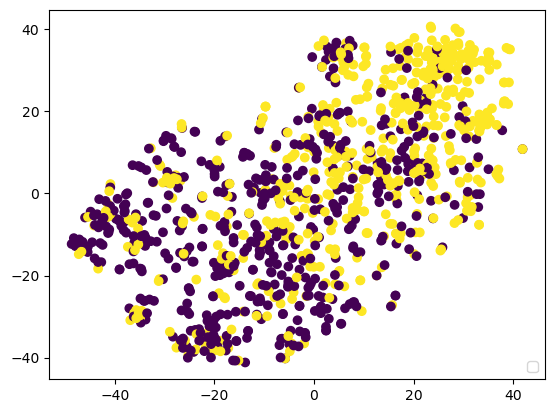

0  
0.0    545
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.8596654275092936
Training MCC Score: 0.7202715884040286
Training F1 Score: 0.8594195462517444
Training AUC VALUE: 0.9311788386115863
Training kappa Score: 0.7190726818775979
Training Precision: 0.88
Training Recall: 0.8286252354048964
Training Sensitivity: 0.8286252354048964
Training Specificity: 0.8899082568807339
Training CCR: 0.8596654275092936
Training PPV: 0.88


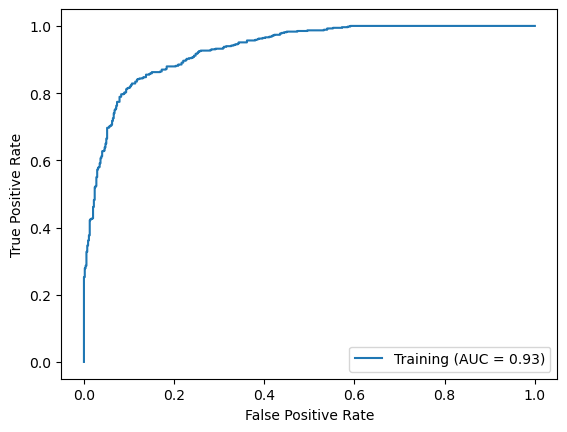

Testing Accuracy: 0.6440677966101694
Testing MCC Score: 0.2883012836269136
Testing F1 Score: 0.6439655172413794
Testing AUC VALUE: 0.6701179177451826
Testing kappa Score: 0.288135593220339
Testing Precision: 0.6271186440677966
Testing Recall: 0.6491228070175439
Testing Sensitivity: 0.6491228070175439
Testing Specificity: 0.639344262295082
Testing CCR: 0.6440677966101694
Testing PPV: 0.6271186440677966


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


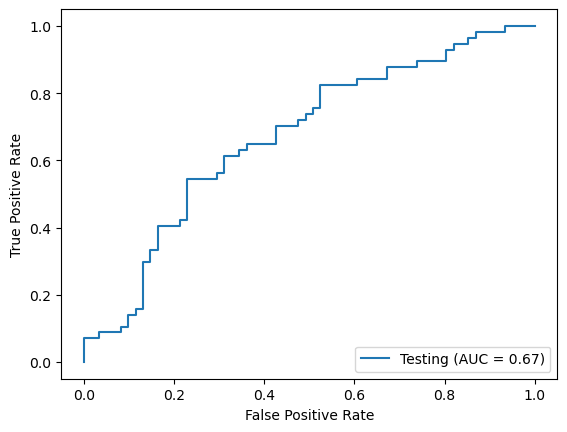

2024-11-04 22:52:52,867:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:52:52,868:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:52:52,869:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #10


C:\Users\DELL\AppData\Local\Temp\ipykernel_91460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


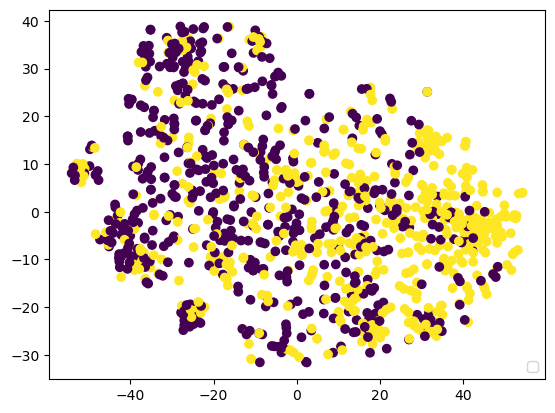

0  
0.0    545
1.0    531
Name: count, dtype: int64
Training Accuracy: 0.8327137546468402
Training MCC Score: 0.6654049487919936
Training F1 Score: 0.832630487383339
Training AUC VALUE: 0.9217038995145044
Training kappa Score: 0.6652898989026181
Training Precision: 0.836852207293666
Training Recall: 0.8210922787193974
Training Sensitivity: 0.8210922787193974
Training Specificity: 0.8440366972477065
Training CCR: 0.8327137546468402
Training PPV: 0.836852207293666


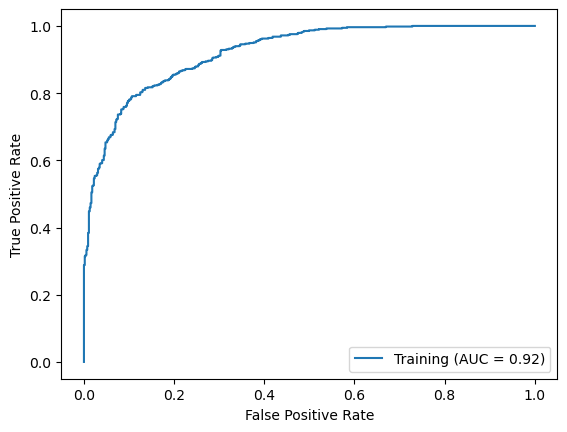

Testing Accuracy: 0.6610169491525424
Testing MCC Score: 0.32221908170066815
Testing F1 Score: 0.6609195402298851
Testing AUC VALUE: 0.7604256542996837
Testing kappa Score: 0.3220338983050848
Testing Precision: 0.6440677966101694
Testing Recall: 0.6666666666666666
Testing Sensitivity: 0.6666666666666666
Testing Specificity: 0.6557377049180327
Testing CCR: 0.6610169491525424
Testing PPV: 0.6440677966101694


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


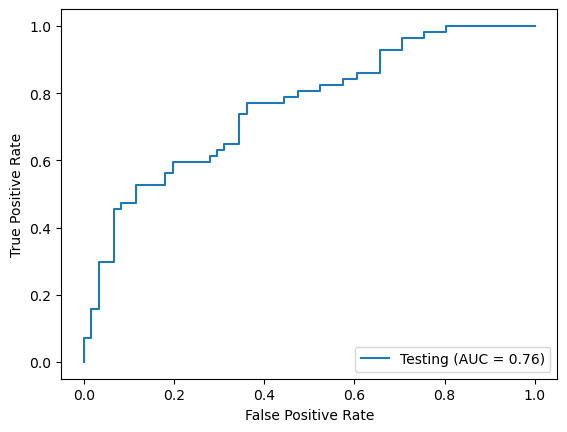

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob)\n    all_labels.extend(Final_Ytrain)\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob)\n    all_labels.extend(Test_y)\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [38]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

Train_Fold_outs_1 = []
Test_Fold_outs_1 = []
models_1 = []

# 用于存储训练和测试集的预测结果和标签

total_metrics = []

# 定义 10 折交叉验证
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 获取特征和标签
X = Data[f_list].values  # 替换 Data 为你的数据集，f_list 为你的特征列表
y = Data['status'].values

Parameters = pd.DataFrame.from_dict(Best_params).iloc[6].to_dict()
print(Parameters)
# 10 折交叉验证
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f'Fold #{fold+1}')
    
    # 获取训练集和测试集
    Train_x, Test_x = X[train_index], X[test_index]
    Train_y, Test_y = y[train_index], y[test_index]
    
    # Upsampling
    Final_Xtrain, Final_Ytrain = Smote(pd.DataFrame(Train_x, columns=f_list), pd.Series(Train_y), 0.5)
    print(Final_Ytrain.value_counts())
    Final_Ytrain = Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype=np.float64)
    Test_x_filtered = pd.DataFrame(Test_x, dtype=np.float64)

    # 使用 KNeighborsClassifier
    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])

    
    # 拟合模型
    rf.fit(Final_Xtrain, Final_Ytrain)
    models_1.append(rf)
    
    # 训练集预测
    y_train_pred = rf.predict(Final_Xtrain)
    y_train_prob = rf.predict_proba(Final_Xtrain)[:, 1]
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred, y_train_prob, Final_Ytrain, 'Training'))

    # 测试集预测
    y_test_pred = rf.predict(Test_x_filtered)
    y_test_prob = rf.predict_proba(Test_x_filtered)[:, 1]
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred, y_test_prob, Test_y, 'Testing'))
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob)
    all_labels.extend(Final_Ytrain)
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob)
    all_labels.extend(Test_y)

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

In [39]:
#Analyse the training metrics sorted by descending Training Accuracy
pd.DataFrame.from_dict(Test_Fold_outs_1).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
6,0.720339,0.440420,0.720158,0.784584,0.440356,0.706897,0.719298,0.719298,0.721311,0.720339,0.706897
3,0.720339,0.440606,0.719836,0.789943,0.440035,0.727273,0.689655,0.689655,0.750000,0.720339,0.727273
5,0.720339,0.439639,0.719351,0.777970,0.439067,0.722222,0.684211,0.684211,0.754098,0.720339,0.722222
7,0.720339,0.444379,0.715746,0.813920,0.436469,0.760870,0.614035,0.614035,0.819672,0.720339,0.760870
2,0.703390,0.406838,0.703369,0.764080,0.406780,0.694915,0.706897,0.706897,0.700000,0.703390,0.694915
0,0.703390,0.407225,0.702342,0.784195,0.405755,0.716981,0.655172,0.655172,0.750000,0.703390,0.716981
4,0.677966,0.354653,0.677131,0.765315,0.354449,0.672727,0.649123,0.649123,0.704918,0.677966,0.672727
9,0.661017,0.322219,0.660920,0.760426,0.322034,0.644068,0.666667,0.666667,0.655738,0.661017,0.644068
8,0.644068,0.288301,0.643966,0.670118,0.288136,0.627119,0.649123,0.649123,0.639344,0.644068,0.627119
1,0.644068,0.287687,0.643658,0.719828,0.287522,0.642857,0.620690,0.620690,0.666667,0.644068,0.642857


<Axes: >

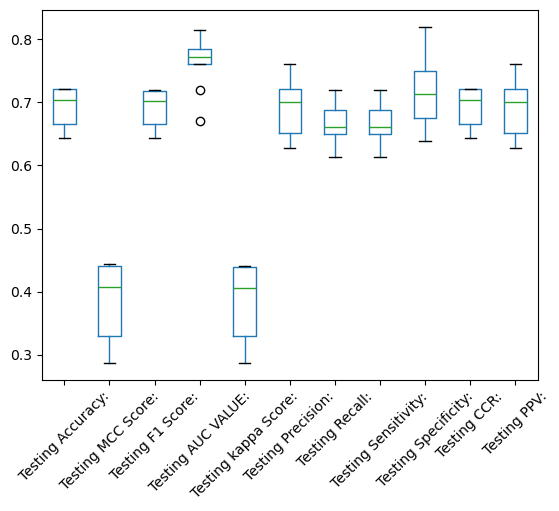

In [40]:
#To visualize the stability of the tuned model with each fold
(pd.DataFrame(Test_Fold_outs_1)).boxplot(grid=False,rot=45)

In [41]:
pd.DataFrame(Test_Fold_outs_1)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.703390,0.407225,0.702342,0.784195,0.405755,0.716981,0.655172,0.655172,0.750000,0.703390,0.716981
1,0.644068,0.287687,0.643658,0.719828,0.287522,0.642857,0.620690,0.620690,0.666667,0.644068,0.642857
2,0.703390,0.406838,0.703369,0.764080,0.406780,0.694915,0.706897,0.706897,0.700000,0.703390,0.694915
3,0.720339,0.440606,0.719836,0.789943,0.440035,0.727273,0.689655,0.689655,0.750000,0.720339,0.727273
4,0.677966,0.354653,0.677131,0.765315,0.354449,0.672727,0.649123,0.649123,0.704918,0.677966,0.672727
5,0.720339,0.439639,0.719351,0.777970,0.439067,0.722222,0.684211,0.684211,0.754098,0.720339,0.722222
6,0.720339,0.440420,0.720158,0.784584,0.440356,0.706897,0.719298,0.719298,0.721311,0.720339,0.706897
7,0.720339,0.444379,0.715746,0.813920,0.436469,0.760870,0.614035,0.614035,0.819672,0.720339,0.760870
8,0.644068,0.288301,0.643966,0.670118,0.288136,0.627119,0.649123,0.649123,0.639344,0.644068,0.627119
9,0.661017,0.322219,0.660920,0.760426,0.322034,0.644068,0.666667,0.666667,0.655738,0.661017,0.644068


In [42]:
TRAIN = Data.drop(['smiles','status'],axis=1)
TRAIN

,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,A1_9,...,E5_118,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127
0,-0.093968,-0.093967,0.093969,0.057746,0.093969,0.093967,-0.093969,-0.093969,-0.093884,0.093948,...,-0.113043,0.045350,-0.047832,-0.075688,-0.014491,0.111776,0.116129,0.118240,-0.035231,0.041989
1,-0.093479,-0.089258,0.069801,-0.090986,-0.082043,-0.043359,0.091742,-0.093448,0.089061,0.093108,...,-0.090673,-0.116404,0.065310,-0.059638,0.008421,-0.018185,-0.046916,-0.002449,0.137647,0.030377
2,-0.094336,-0.094267,-0.061746,-0.030467,-0.084787,-0.086779,0.066083,-0.093192,0.082983,0.091931,...,-0.096881,-0.104732,0.103063,0.032510,0.105347,-0.053153,0.019736,-0.092859,0.018258,0.047839
3,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,-0.029744,...,-0.012364,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740
4,-0.094767,0.099285,-0.069983,0.078858,0.014583,0.099227,0.099023,-0.099302,-0.096730,0.058144,...,-0.026042,0.043367,-0.080618,0.056817,0.146075,0.018187,-0.044958,0.020963,0.084850,0.095499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,-0.093038,-0.094335,0.095204,-0.046846,0.095202,0.063424,-0.095204,-0.095204,-0.095197,0.095203,...,-0.051478,0.081276,-0.075611,0.121933,0.039703,0.006569,0.126562,0.004939,0.047710,-0.080002
1176,-0.093343,0.087515,-0.104545,-0.101462,-0.099453,0.056369,0.107227,0.108413,-0.046003,0.040802,...,-0.004512,-0.173945,0.010049,-0.053734,-0.035837,-0.067844,-0.067368,-0.062793,0.003713,0.078850
1177,0.086594,0.097406,0.096966,-0.097145,0.097028,-0.091569,-0.071954,0.097492,0.096533,0.089626,...,-0.159002,-0.141212,-0.046718,-0.069887,0.049093,-0.093039,-0.117753,0.079444,0.002861,0.134517
1178,-0.100737,-0.058030,0.092190,0.082473,0.097876,0.100723,0.051282,-0.100834,-0.095762,0.092319,...,-0.032796,0.044552,-0.055257,0.027439,0.102704,-0.073929,-0.123453,0.121928,-0.054320,0.099869


In [43]:
TRAIN = TRAIN[f_list] #Use features of the selected (hyperparameter tuned) model here
TRAIN

,B1_27,B1_31,B2_98,C1_13,C1_41,C1_95,C1_102,C1_103,D1_8,D1_64,...,E4_93,E4_111,E4_113,E4_117,E4_118,E4_122,E4_125,E5_53,E5_108,E5_117
0,0.021282,-0.001311,0.109228,-0.031276,-0.100030,0.114068,-0.113739,0.075949,-0.076255,-0.068156,...,0.092698,-0.111502,0.109297,0.119676,0.119083,0.091064,-0.111305,-0.097981,0.131731,0.142912
1,0.104418,0.132354,0.060779,-0.103423,-0.099634,0.102270,-0.080365,-0.076418,-0.111999,-0.112172,...,-0.095540,-0.021647,-0.065752,0.073527,0.091587,0.115730,-0.051649,-0.031631,0.079500,0.081074
2,0.076497,0.129976,0.122991,-0.108787,-0.105905,-0.056438,-0.126582,-0.029031,-0.116056,-0.116086,...,-0.081839,-0.006257,0.054363,0.106258,0.106366,0.106495,-0.094931,-0.106638,0.106629,0.107427
3,0.051903,0.149349,0.046690,0.104251,0.043404,0.028632,-0.116665,0.077649,-0.106910,-0.022850,...,0.114542,0.003088,0.061197,0.070241,0.136066,0.129967,-0.115071,-0.125696,0.020830,0.126525
4,0.085856,0.121691,0.120398,-0.132713,0.015499,-0.016436,-0.096315,0.101646,-0.090788,-0.128877,...,0.003331,0.066510,0.095055,-0.052314,0.078827,-0.021361,0.011509,-0.001393,-0.034657,0.100837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,-0.085676,0.070179,0.112224,-0.071059,-0.100445,0.066494,-0.093219,0.006051,-0.119554,-0.060295,...,-0.050272,-0.122016,0.117909,0.128342,0.126746,0.087086,-0.074813,-0.003204,0.036805,0.124033
1176,-0.057777,-0.163002,0.010692,0.034058,-0.038705,-0.041204,-0.131488,-0.001742,0.054650,0.114516,...,-0.107591,0.045306,0.088979,0.121596,-0.053177,-0.100179,0.099780,-0.061773,0.110431,-0.141453
1177,0.008782,0.167160,0.019633,0.109990,-0.000400,0.111348,-0.112660,-0.106405,-0.067818,-0.111421,...,-0.098062,-0.090202,0.114653,0.089040,0.104806,0.040069,0.096061,0.067169,0.037165,-0.050409
1178,0.081422,0.018267,-0.029795,-0.074055,-0.104008,0.105164,0.103847,-0.073158,-0.103934,0.104535,...,-0.056065,0.009779,0.048347,-0.114805,0.116286,0.023295,0.084642,0.058122,-0.035496,-0.112377


In [44]:
Y = Data['status']

In [45]:
#Fitting the model on whole data
fitted = models_1[6].fit(TRAIN,Y)
fitted

RandomForestClassifier(max_depth=40, max_features='sqrt', min_samples_leaf=13,
                       min_samples_split=22, n_estimators=67)

In [46]:
#Save the final model
joblib.dump(fitted, 'AID_1208_RF.pkl')

['AID_1208_RF.pkl']

In [48]:
import joblib
import pandas as pd

class model_AID_1208:
    def __init__(self, test):        
        self.test = test

    def extract_feature(self, data):        
        # 读取特征文件
        F_names = pd.read_csv('AID_1208_features.csv')
        features = F_names.iloc[:, 0].tolist()
        return data[features]

    def get_labels(self, pred_test):
        # 根据概率预测类别
        test_pred = []
        for i in range(pred_test.shape[0]):
            if pred_test[i][0] > pred_test[i][1]:  # 类别 0 概率更大
                test_pred.append(0)
            else:
                test_pred.append(1)  # 类别 1 概率更大
        return test_pred

    def test_model(self):
        # 提取特征并加载本地的 KNN 模型进行预测
        test = self.test
        test_filtered = self.extract_feature(test.drop(['smiles'], axis=1))
        
        # 本地加载 KNN 模型
        model = joblib.load('AID_1208_RF.pkl')
        
        # 使用模型进行预测
        probs = model.predict_proba(test_filtered)
        
        # 获取预测类别
        preds = self.get_labels(probs)
        
        return probs, preds


def AID_1208(smi_list):
    Feature_data = pd.DataFrame()
    Feature_data['smiles'] = smi_list

    Sig_Carcin = Feature_Signaturizer(smi_list)
    
    # 保留删除前的索引
    original_index = Sig_Carcin.index
    
    # 删除缺失值的行
    Sig_Carcin_clean = Sig_Carcin.dropna()

    # 使用清理过的数据进行模型测试
    m4 = model_AID_1208(Sig_Carcin_clean)  # 假设这里的模型函数改为 model_apoptosis
    probs, preds = m4.test_model()

    # 创建一个与原始索引匹配的结果数组
    Feature_data['AID_1208_0'] = None
    Feature_data['AID_1208_1'] = None
    Feature_data['AID_1208_preds'] = None

    # 填充有效的预测结果
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1208_0'] = probs[:, 0]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1208_1'] = probs[:, 1]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1208_preds'] = preds

    return Feature_data


In [19]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'MKETn_Training_Data.csv') ### features in columns,molecules in rows
data

,SMILES,Name,CID,InChI,IUPAC,Status,Source
0,[As],Arsenic,5359596.0,1S/As,arsenic,1,CCRIS
1,[Be],Beryllium,5460467.0,1S/Be,beryllium,1,CCRIS
2,[Be]=O,Beryllium oxide,14775.0,1S/Be.O,oxoberyllium,1,CCRIS
3,[Be+2].[OH-].[OH-],Dihydroxyberyllium,25879.0,1S/Be.2H2O/h;2*1H2/q+2;;/p-2,beryllium;dihydroxide,1,CCRIS
4,[C-]#[Si+],Silicon carbide,9863.0,1S/CSi/c1-2,methanidylidynesilanylium,1,CCRIS
...,...,...,...,...,...,...,...
461,P#[Ga],Gallium phosphide,82901.0,1S/Ga.P,gallanylidynephosphane,0,CCRIS
462,S=[Cd],Cadmium sulfide,14783.0,1S/Cd.S,sulfanylidenecadmium,1,CCRIS
463,S=[Ni],Nickel sulfide,28094.0,1S/Ni.S,sulfanylidenenickel,1,CCRIS
464,S=P(N1CC1)(N1CC1)N1CCOCC1,Morzid,62432.0,"1S/C8H16N3OPS/c14-13(9-1-2-9,10-3-4-10)11-5-7-...",bis(aziridin-1-yl)-morpholin-4-yl-sulfanyliden...,1,CCRIS
